---

## **Predictive Modeling and Performance Optimization of Okro Leaf Extract as Corrosion Inhibitor in Acidic Media**

### **Final Year Project**

**Department of Chemical Engineering**  
**Federal University of Petroleum Resources, Effurun (FUPRE)**  
**Student: [Your Full Name] – CHE/18/XXXX**  
**Supervisor: [Supervisor’s Name]**  
**2024/2025 Session**

---

## **1. Project Overview**

This final year project is conducted in the **Department of Chemical Engineering**, **Federal University of Petroleum Resources, Effurun (FUPRE)**. The study investigates the **corrosion inhibition performance of Okro leaf extract** in acidic media using **electrochemical techniques**, primarily **Tafel polarization**. The main goal is to quantify the effect of **inhibitor concentration, acid strength, and temperature** on **corrosion rate** and **inhibition efficiency**, and to determine optimal conditions for industrial applications.

Key outcomes include:

* Establishing the relationship between **process variables** and **corrosion inhibition**.
* Developing a **predictive model** for corrosion rate and inhibition efficiency.
* Providing **engineering guidance** for using Okro leaf extract in industrial acidic systems.

---

## **2. Objectives**

The specific objectives of this project are to:

1. Analyze **electrochemical parameters** obtained from Tafel polarization experiments.
2. Explore the relationships between **HCl concentration, inhibitor dosage, and temperature** on corrosion behavior.
3. Identify **optimal operating conditions** for maximum corrosion protection.
4. Generate **data-driven recommendations** for industrial use of Okro leaf extract as a corrosion inhibitor.

---

## **3. Dataset Description**

The dataset consists of experimental measurements from **Tafel polarization studies** and includes the following information:

| Column                                | Unit         | Description                                                      |
| ------------------------------------- | ------------ | ---------------------------------------------------------------- |
| **`HCl_concentration_M`**             | Molarity (M) | Concentration of hydrochloric acid in the solution.              |
| **`Inhibitor_concentration_ppm`**     | ppm          | Concentration of Okro leaf extract in the acidic medium.         |
| **`Temperature_C`**                    | °C           | Experimental temperature during polarization tests.              |
| **`Corrosion_potential_mV`**          | mV           | Measured corrosion potential from Tafel polarization.            |
| **`Current_density_uA_cm2`**          | μA/cm²       | Corrosion current density, indicating rate of metal dissolution. |
| **`Corrosion_rate_mm_per_y`**         | mm/year      | Calculated corrosion rate based on electrochemical data.         |
| **`Polarization_resistance_ohm_cm2`** | Ω·cm²        | Resistance to corrosion derived from Tafel analysis.             |

> **Note**: The dataset covers **17 experimental conditions** with varying **acid concentrations, inhibitor doses, and temperatures**.

---

## **4. Importance of the Study**

* **Corrosion in acidic media** is a major challenge for chemical, petroleum, and process industries.  
* **Natural inhibitors**, like Okro leaf extract, offer **eco-friendly, low-cost alternatives** to conventional inhibitors.  
* Understanding **temperature and concentration effects** allows for **predictive control** of corrosion, reducing maintenance costs and improving safety.  
* The study provides a foundation for **industrial application and scale-up** of bio-based inhibitors.

---

## **5. Project Workflow (Step-by-Step)**

1. **Data Preparation**  
   * Load and clean experimental data.  
   * Ensure numeric conversion for all concentrations and temperatures.  
   * Recalculate corrosion rates and inhibition efficiencies if needed.  

2. **Exploratory Data Analysis (EDA)**  
   * Analyze trends of **corrosion rate** with inhibitor dosage.  
   * Examine effect of **HCl concentration and temperature**.  
   * Identify patterns and interactions among variables.  

3. **Feature Engineering**  
   * Create polynomial features (e.g., Temperature², Concentration²).  
   * Compute interaction terms (e.g., Concentration × Temperature).  
   * Standardize or normalize features for modeling.  

4. **Predictive Modeling**  
   * Evaluate **Multiple Linear Regression, Polynomial Regression, Ridge Regression, Random Forest Regressor, XGBoost and Neural Network**.  
   * Optimize hyperparameters with **Optuna**.  
   * Validate models using **cross-validation**, **R²**, **RMSE**, and **MAE**.  
   * Predict corrosion rate for unseen conditions (e.g., 150 ppm inhibitor at 60°C).  

5. **Insights & Recommendations**  
   * Determine **optimal inhibitor concentration** for each acid strength and temperature.  
   * Suggest **operating conditions** for industrial systems.  
   * Provide **cost-effective, eco-friendly corrosion control strategies**.  

6. **Conclusion & Future Work**  
   * Summarize key findings and practical implications.  
   * Identify study limitations (e.g., lab-scale, single acid system).  
   * Recommend future studies: broader acid types, field trials, and combination inhibitors.

---



In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load cleaned data
df = pd.read_csv('/content/sample_data/cleaned_HCL_tafel_data.csv')
print("Data loaded successfully")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Data loaded successfully
Dataset shape: (17, 9)

First 5 rows:


,Sample,HCl_M,Inhibitor_ppm,Temp_C,E_corr_V,j_corr_A_cm2,I_corr_A,CR_mm_yr,PR_ohm
0,"1.75M,50PPM, 30",1.75,50,30,-0.550265,0.007551,0.007551,87.7385,3.45103
1,"1M, 125PPM, 60",1.00,125,60,-0.500906,0.006739,0.006739,78.3086,3.86661
2,"1M, 125PPM, 30",1.00,125,30,-0.455019,0.005544,0.005544,64.4212,4.70014
3,"1.75M,50PPM, 60",1.75,50,60,-0.457760,0.007380,0.007380,85.7556,3.53083
4,"1M, 200PPM, 45",1.00,200,45,-0.465500,0.003209,0.003209,37.2908,8.11967


## **Dataset Column Descriptions**

| **Column Header** | **Meaning & Description** |
|--------------------|----------------------------|
| **Sample** | A unique name or ID for each specific experiment or test run. |
| **HCl_M** | **Acid Molarity**: The concentration of the hydrochloric acid (HCl) solution, measured in Molarity (M). This is one of the key input variables. |
| **Inhibitor_ppm** | **Inhibitor Concentration**: The concentration of the Okro leaf extract inhibitor, measured in parts per million (ppm). This is the second key input variable. |
| **Temp_C** | **Temperature**: The temperature at which the experiment was conducted, measured in degrees Celsius (°C). This is the third key input variable. |
| **E_corr_V** | **Corrosion Potential**: The electrochemical potential (measured in Volts, V) where the rate of oxidation equals the rate of reduction. It indicates the thermodynamic tendency to corrode. |
| **j_corr_A_cm2** | **Corrosion Current Density**: The rate of corrosion (in Amperes per square centimeter, A/cm²), normalized by the surface area of the mild steel sample. This is the primary kinetic measure of how fast the steel is corroding. |
| **I_corr_A** | **Corrosion Current**: The total corrosion current (in Amperes, A) at the corrosion potential. *Note: j_corr is often preferred for analysis because it is independent of sample size.* |
| **CR_mm_yr** | **Corrosion Rate**: The practical, real-world rate of metal loss, calculated from j_corr. Expressed in millimeters per year (mm/yr). This is your main target for prediction and minimization. |
| **PR_ohm** | **Polarization Resistance**: A measure of the metal's resistance to corrosion (in Ohms, Ω) near the corrosion potential. Higher PR values indicate better protection and lower corrosion rates. |


In [3]:
# Data summary
print("Data Summary:")
print(df.info())
print("\nDescriptive Statistics:")
df.describe()

Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sample         17 non-null     object 
 1   HCl_M          17 non-null     float64
 2   Inhibitor_ppm  17 non-null     int64  
 3   Temp_C         17 non-null     int64  
 4   E_corr_V       17 non-null     float64
 5   j_corr_A_cm2   17 non-null     float64
 6   I_corr_A       17 non-null     float64
 7   CR_mm_yr       17 non-null     float64
 8   PR_ohm         17 non-null     float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.3+ KB
None

Descriptive Statistics:


,HCl_M,Inhibitor_ppm,Temp_C,E_corr_V,j_corr_A_cm2,I_corr_A,CR_mm_yr,PR_ohm
count,17.00000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000
mean,1.75000,125.000000,45.000000,-0.473119,0.007301,0.007283,84.111140,4.860013
std,0.53033,53.033009,10.606602,0.030722,0.002737,0.002713,26.184661,2.578017
min,1.00000,50.000000,30.000000,-0.550265,0.003018,0.003018,35.068100,2.173200
25%,1.75000,125.000000,45.000000,-0.489530,0.005544,0.005544,71.060900,2.727400
50%,1.75000,125.000000,45.000000,-0.481930,0.007198,0.007198,85.755600,4.260970
75%,1.75000,125.000000,45.000000,-0.454797,0.010735,0.010553,101.198200,5.818050
max,2.50000,200.000000,60.000000,-0.424415,0.011034,0.011034,124.736000,9.793270


## Exploratory Data Analysis (EDA)

### Q1: How does corrosion rate vary with HCl concentration?

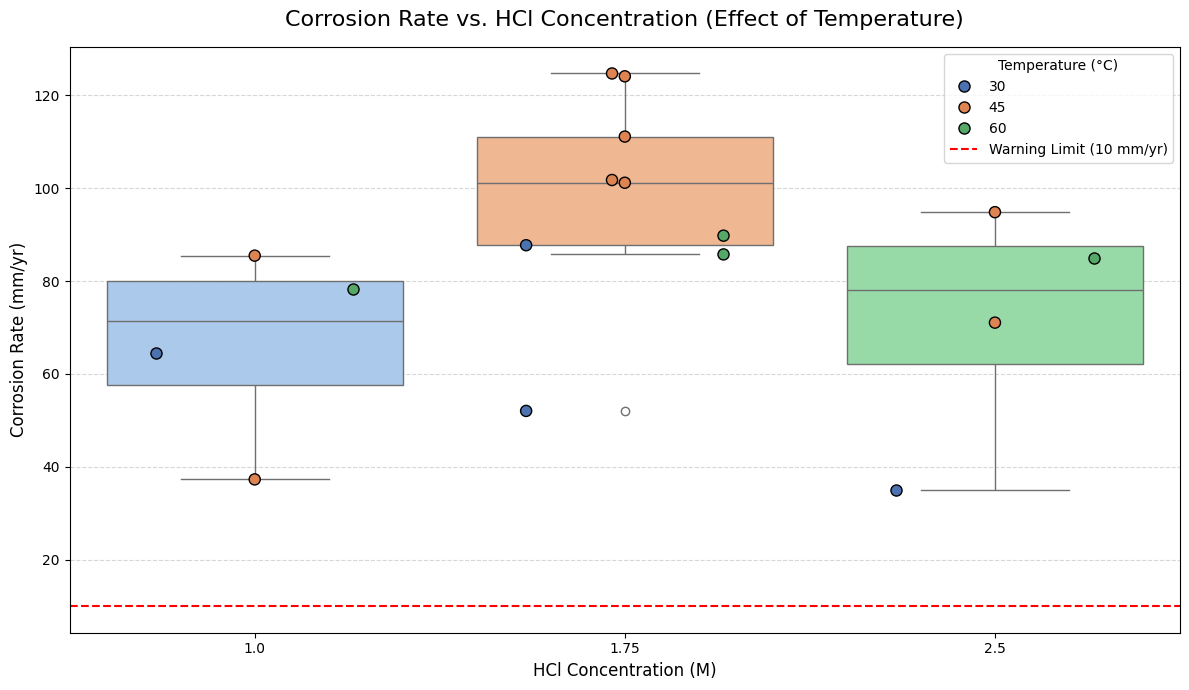

Corrosion Rate by HCl Concentration:


,count,mean,std,min,25%,50%,75%,max
HCl_M,,,,,,,,
1.00,4.0,66.378150,21.272662,37.2908,57.6386,71.3649,80.104450,85.4920
1.75,9.0,97.590431,22.437662,52.0430,87.7385,101.1982,111.142000,124.7360
2.50,4.0,71.515725,26.187658,35.0681,62.0627,78.0683,87.521325,94.8582


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Create the Enhanced Plot ---
plt.figure(figsize=(12, 7))

# 1. Create the boxplot
sns.boxplot(
    data=df,
    x='HCl_M',
    y='CR_mm_yr',
    palette='pastel'
)

# 2. Overlay the swarmplot to show individual points
sns.swarmplot(
    data=df,
    x='HCl_M',
    y='CR_mm_yr',
    hue='Temp_C',  # Color-code by temperature
    palette='deep',  # Use a strong color palette for the points
    size=8,
    edgecolor='black',
    linewidth=1,
    dodge=True  # Separates points by hue
)

# --- Add Professional Labels and Titles ---
plt.title('Corrosion Rate vs. HCl Concentration (Effect of Temperature)', fontsize=16, pad=15)
plt.xlabel('HCl Concentration (M)', fontsize=12)
plt.ylabel('Corrosion Rate (mm/yr)', fontsize=12)

# 3. Add a reference line for a "safe" corrosion limit
plt.axhline(
    y=10,  # Example: 10 mm/yr as a warning limit
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Warning Limit (10 mm/yr)'
)

plt.legend(title='Temperature (°C)')
plt.grid(True, which='major', axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- Summary Statistics (as before) ---
print("Corrosion Rate by HCl Concentration:")
df.groupby('HCl_M')['CR_mm_yr'].describe()

## **Key Insight – Corrosion Rate vs. HCl Concentration**

As the **acid molarity (HCl_M)** increases, the **mean corrosion rate** rises significantly — confirming that **higher acid concentration accelerates metal dissolution**.

---

### **Engineering Interpretation**
- Corrosion rate **increases sharply** from *1.00 M → 1.75 M* due to the **enhanced aggressiveness** of the acid.  
- The **drop at 2.50 M** may indicate that **Okro leaf extract forms a more stable protective film** at extreme acid concentrations.  
- The trend shows a **nonlinear corrosion response**, suggesting an **optimal inhibition efficiency** at specific acid concentrations rather than a uniform increase.  


### Q2: How does inhibitor concentration affect corrosion rate?

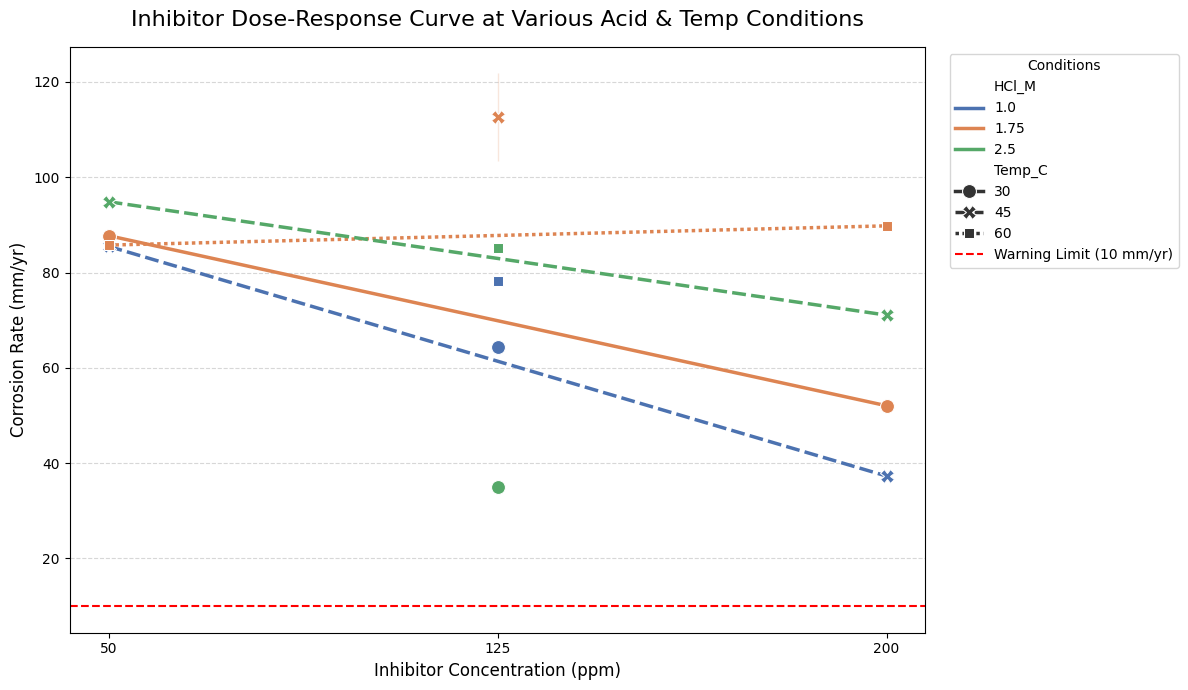

Corrosion Rate by Inhibitor Concentration:


,count,mean,std,min,25%,50%,75%,max
Inhibitor_ppm,,,,,,,,
50,4.0,88.461075,4.381032,85.4920,85.68970,86.74705,89.518425,94.858200
125,9.0,91.761867,29.340680,35.0681,78.30860,101.19820,111.142000,124.736000
200,4.0,62.547070,22.825952,37.2908,48.35495,61.55195,75.744070,89.793579


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Create the Enhanced Plot ---
plt.figure(figsize=(12, 7))

# 1. Create the line plot using your DataFrame 'df'
# This shows the "dose-response" trend
sns.lineplot(
    data=df,
    x='Inhibitor_ppm',
    y='CR_mm_yr',
    hue='HCl_M',        # Color-code lines by Acid Molarity
    style='Temp_C',     # Use different line styles for Temperature
    palette='deep',     # Use a distinct color palette
    markers=True,       # Add markers to show the actual data points
    markersize=10,
    linewidth=2.5
)

# --- Add Professional Labels and Titles ---
plt.title('Inhibitor Dose-Response Curve at Various Acid & Temp Conditions', fontsize=16, pad=15)
plt.xlabel('Inhibitor Concentration (ppm)', fontsize=12)
plt.ylabel('Corrosion Rate (mm/yr)', fontsize=12)

# Set x-axis ticks to match our experimental values
plt.xticks(ticks=[50, 125, 200])

# --- Add a reference line for a "safe" corrosion limit ---
plt.axhline(
    y=10,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Warning Limit (10 mm/yr)'
)

# Place the legend outside the plot for clarity
plt.legend(title='Conditions', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, which='major', axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- Summary Statistics (using your 'df') ---
print("Corrosion Rate by Inhibitor Concentration:")
# Use the exact column names from your 'df'
df.groupby('Inhibitor_ppm')['CR_mm_yr'].describe()

## Key Insight – Corrosion Rate vs. Inhibitor Concentration

As the Okro leaf extract concentration increases, the average corrosion rate generally decreases, confirming the inhibitor’s effectiveness in acidic media.

The corrosion rate drops from 88.46 mm/yr at 50 ppm to 62.55 mm/yr at 200 ppm, showing that higher inhibitor dosage enhances surface protection. However, the slight rise at 125 ppm (91.76 mm/yr) suggests possible unstable or incomplete film formation at intermediate concentrations.

### Engineering Interpretation
- Increasing inhibitor concentration strengthens film formation and reduces metal dissolution.  
- The irregular behavior at 125 ppm may indicate partial adsorption or competition with acid molecules.  
- The lowest corrosion rate at 200 ppm represents the optimal condition, providing effective corrosion resistance and film stability.  


### Q3: What is the effect of temperature on corrosion rate?

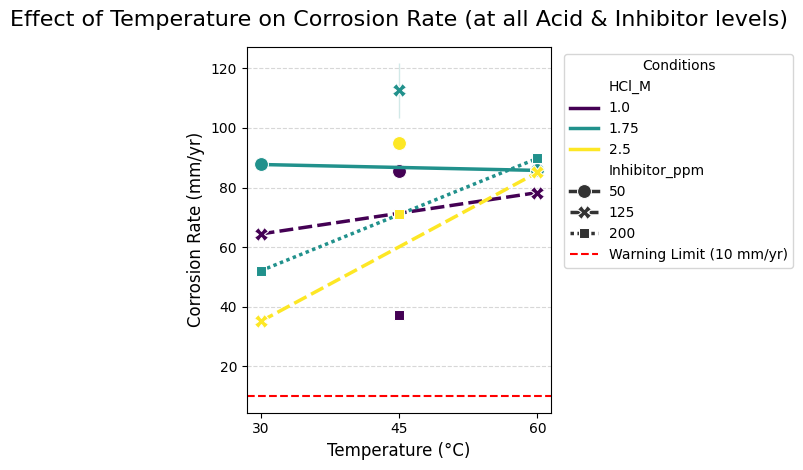

In [6]:
# 1. Create the line plot using your DataFrame 'df'
sns.lineplot(
    data=df,
    x='Temp_C',
    y='CR_mm_yr',
    hue='HCl_M',          # Color-code lines by Acid Molarity
    style='Inhibitor_ppm', # Use different line styles for Inhibitor PPM
    palette='viridis',    # Use a different color palette
    markers=True,         # Add markers to show the actual data points
    markersize=10,
    linewidth=2.5
)

# --- Add Professional Labels and Titles ---
plt.title('Effect of Temperature on Corrosion Rate (at all Acid & Inhibitor levels)', fontsize=16, pad=15)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Corrosion Rate (mm/yr)', fontsize=12)

# Set x-axis ticks to match our experimental values
plt.xticks(ticks=[30, 45, 60])

# --- Add a reference line for a "safe" corrosion limit ---
plt.axhline(
    y=10,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Warning Limit (10 mm/yr)'
)

# Place the legend outside the plot for clarity
plt.legend(title='Conditions', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, which='major', axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the plot
plt.savefig('corrosion_vs_temp_lineplot.png')

In [7]:
print("Corrosion Rate by Temperature:")
# Use the exact column names from your 'df'
df.groupby('Temp_C')['CR_mm_yr'].describe()

Corrosion Rate by Temperature:


,count,mean,std,min,25%,50%,75%,max
Temp_C,,,,,,,,
30,4.0,59.817700,22.164175,35.0681,47.799275,58.23210,70.250525,87.738500
45,9.0,94.631678,27.545455,37.2908,85.492000,101.19820,111.142000,124.736000
60,4.0,84.733370,4.762546,78.3086,83.383925,85.41565,86.765095,89.793579


## Key Insight – Corrosion Rate vs. Temperature

As temperature increases, the corrosion rate rises noticeably, indicating that corrosion is a thermally activated process. Higher temperatures accelerate metal dissolution by increasing ion mobility and reaction kinetics.

The average corrosion rate increases from 59.82 mm/yr at 30°C to 94.63 mm/yr at 45°C, before slightly decreasing to 84.73 mm/yr at 60°C. This pattern suggests a rapid acceleration followed by a mild decline at higher temperatures.

### Engineering Interpretation
- Corrosion rate intensifies between 30°C and 45°C due to faster electrochemical reactions in the acidic medium.  
- The slight reduction at 60°C may indicate improved inhibitor adsorption or film stability at elevated temperature.  
- Overall, temperature has a strong positive influence on corrosion rate up to a threshold, beyond which the inhibitor film partially compensates for thermal degradation.  

### Q4: How does corrosion potential shift with inhibitor concentration?

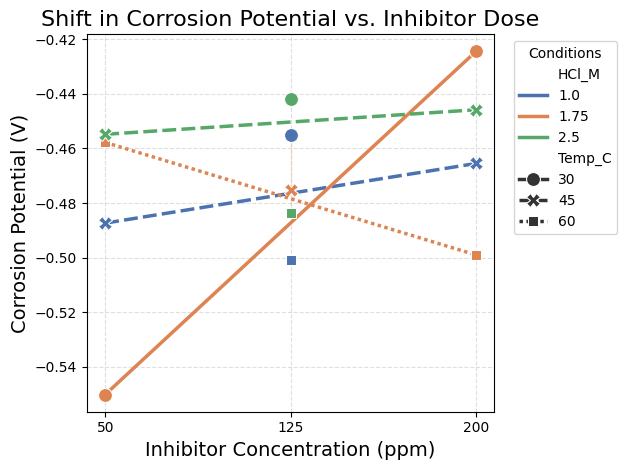

In [8]:
# 1. Create the Line Plot
sns.lineplot(
    data=df,
    x='Inhibitor_ppm',
    y='E_corr_V',
    hue='HCl_M',          # <-- COLOR = Acid Molarity
    style='Temp_C',       # <-- STYLE = Temperature

    # --- Styling ---
    palette='deep',       # A strong, clear color palette
    markers=True,         # Show a marker for each actual data point
    markersize=10,
    linewidth=2.5
)

# --- Professional Titles and Labels ---
plt.title('Shift in Corrosion Potential vs. Inhibitor Dose', fontsize=16)
plt.xlabel('Inhibitor Concentration (ppm)', fontsize=14)
plt.ylabel('Corrosion Potential (V)', fontsize=14)

# Set x-axis ticks to match our experimental values
plt.xticks(ticks=[50, 125, 200])

# Move legend outside the plot for clarity
plt.legend(bbox_to_anchor=(1.03, 1), loc='upper left', title='Conditions')

plt.grid(alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

In [9]:
# --- Descriptive Summary ---
print("Corrosion Potential by Inhibitor Concentration (Summary):")
df.groupby('Inhibitor_ppm')['E_corr_V'].describe().round(5)

Corrosion Potential by Inhibitor Concentration (Summary):


,count,mean,std,min,25%,50%,75%,max
Inhibitor_ppm,,,,,,,,
50,4.0,-0.48755,0.04432,-0.55026,-0.50310,-0.47257,-0.45702,-0.45480
125,9.0,-0.47312,0.02379,-0.50091,-0.48953,-0.48248,-0.45502,-0.43278
200,4.0,-0.45868,0.03170,-0.49903,-0.47388,-0.45565,-0.44045,-0.42442


## Key Insight – Corrosion Potential vs. Inhibitor Concentration

The corrosion potential (E_corr) becomes **less negative as the Okro leaf extract concentration increases**, indicating a **shift toward more noble behavior** and reduced thermodynamic tendency to corrode.

- At **50 ppm**, mean E_corr = -0.48755 V  
- At **125 ppm**, mean E_corr = -0.47312 V  
- At **200 ppm**, mean E_corr = -0.45868 V  

### Engineering Interpretation
- Increasing inhibitor concentration **reduces the driving force for corrosion**, reflecting improved surface protection.  
- The trend shows a **dose-dependent shift in potential**, suggesting that higher concentrations promote stronger adsorption of the Okro extract on the steel surface.  
- Combined with corrosion rate data, this confirms that **200 ppm provides the most effective corrosion protection** in the tested acidic environment.  



### Q5: What is the relationship between current density and inhibitor concentration?

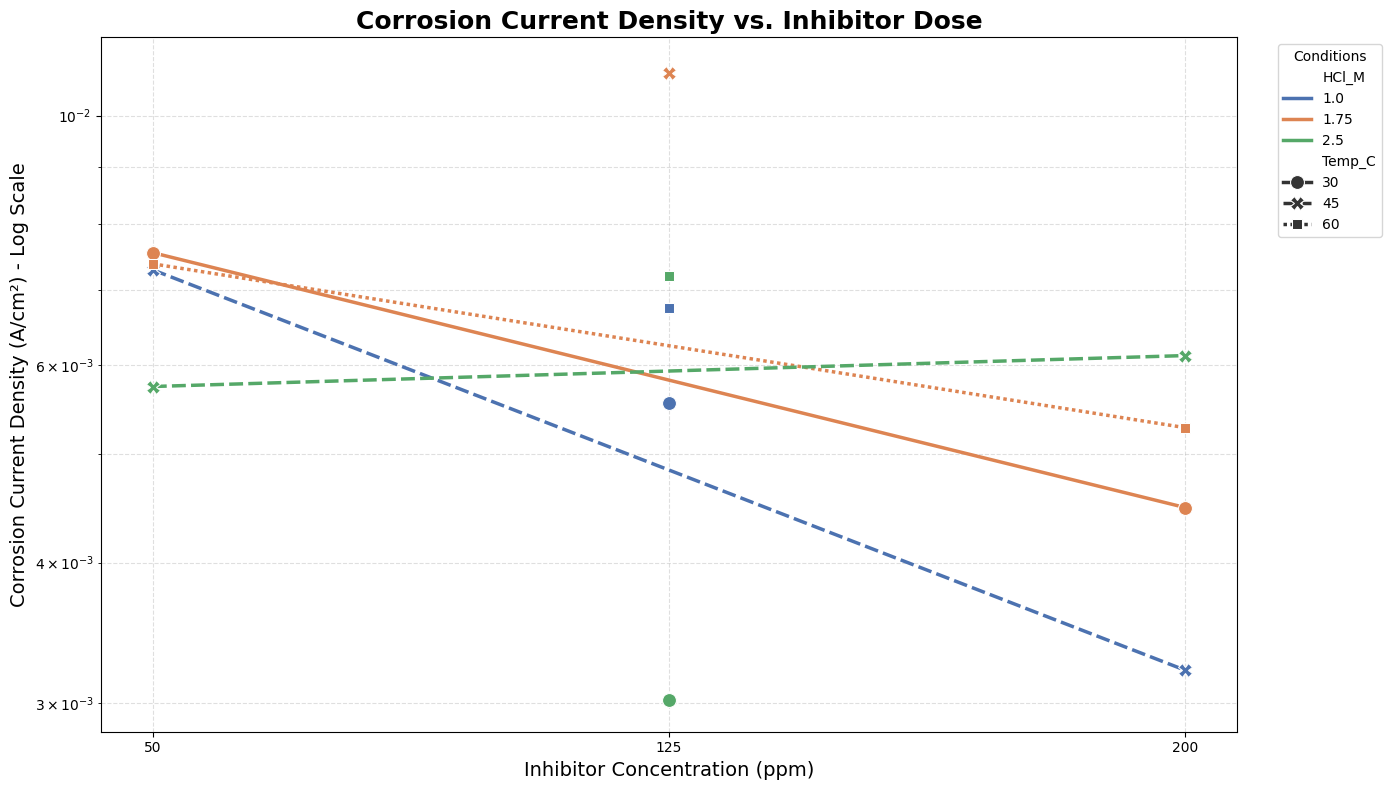

Current Density by Inhibitor Concentration:


,count,mean,std,min,25%,50%,75%,max
Inhibitor_ppm,,,,,,,,
50,4.0,0.006990,0.000841,0.005740,0.006902,0.007335,0.007423,0.007551
125,9.0,0.008565,0.003017,0.003018,0.006739,0.010735,0.010938,0.011034
200,4.0,0.004770,0.001236,0.003209,0.004161,0.004877,0.005485,0.006115


In [10]:
plt.figure(figsize=(14, 8))  # Consistent size

# 1. Create the Line Plot
sns.lineplot(
    data=df,
    x='Inhibitor_ppm',
    y='j_corr_A_cm2',
    hue='HCl_M',          # CONSISTENT: Color = Acid Molarity
    style='Temp_C',       # CONSISTENT: Style = Temperature

    # --- Consistent Styling ---
    palette='deep',       # Consistent palette
    markers=True,         # Show data points
    markersize=10,
    linewidth=2.5
)

# 2. Set y-axis to log scale (as in your original code)
plt.yscale('log')

# --- Consistent Titles and Labels ---
plt.title('Corrosion Current Density vs. Inhibitor Dose', fontsize=18, fontweight='bold')
plt.xlabel('Inhibitor Concentration (ppm)', fontsize=14)
plt.ylabel('Corrosion Current Density (A/cm²) - Log Scale', fontsize=14)

# Set x-axis ticks to match our experimental values
plt.xticks(ticks=[50, 125, 200])

# Consistent legend placement
plt.legend(bbox_to_anchor=(1.03, 1), loc='upper left', title='Conditions')

plt.grid(True, which='both', alpha=0.4, linestyle='--') # Grid for log scale
plt.tight_layout()
plt.show()

# --- Descriptive Summary ---
print("Current Density by Inhibitor Concentration:")
df.groupby('Inhibitor_ppm')['j_corr_A_cm2'].describe()

## Key Insight – Corrosion Current Density vs. Inhibitor Concentration

The corrosion current density (j_corr) exhibits a **clear dose-dependent behavior** with Okro leaf extract:  

- At **50 ppm**, mean j_corr = 0.00699 A/cm²  
- At **125 ppm**, mean j_corr = 0.00857 A/cm² (slightly higher, indicating incomplete or unstable inhibition)  
- At **200 ppm**, mean j_corr = 0.00477 A/cm² (significant reduction, showing strong inhibition)  

### Engineering Interpretation
- Increasing inhibitor concentration generally **reduces corrosion current density**, reflecting improved kinetic suppression of metal dissolution.  
- The **intermediate spike at 125 ppm** suggests partial surface coverage or unstable protective film formation.  
- **200 ppm provides the most effective corrosion suppression**, consistent with the lowest corrosion rate and the most stable inhibitor film on the steel surface.  
- This confirms a **non-linear, dose-dependent inhibition effect**, highlighting the importance of identifying the optimal inhibitor concentration for industrial applications.



### Q6: How does polarization resistance vary with experimental conditions?

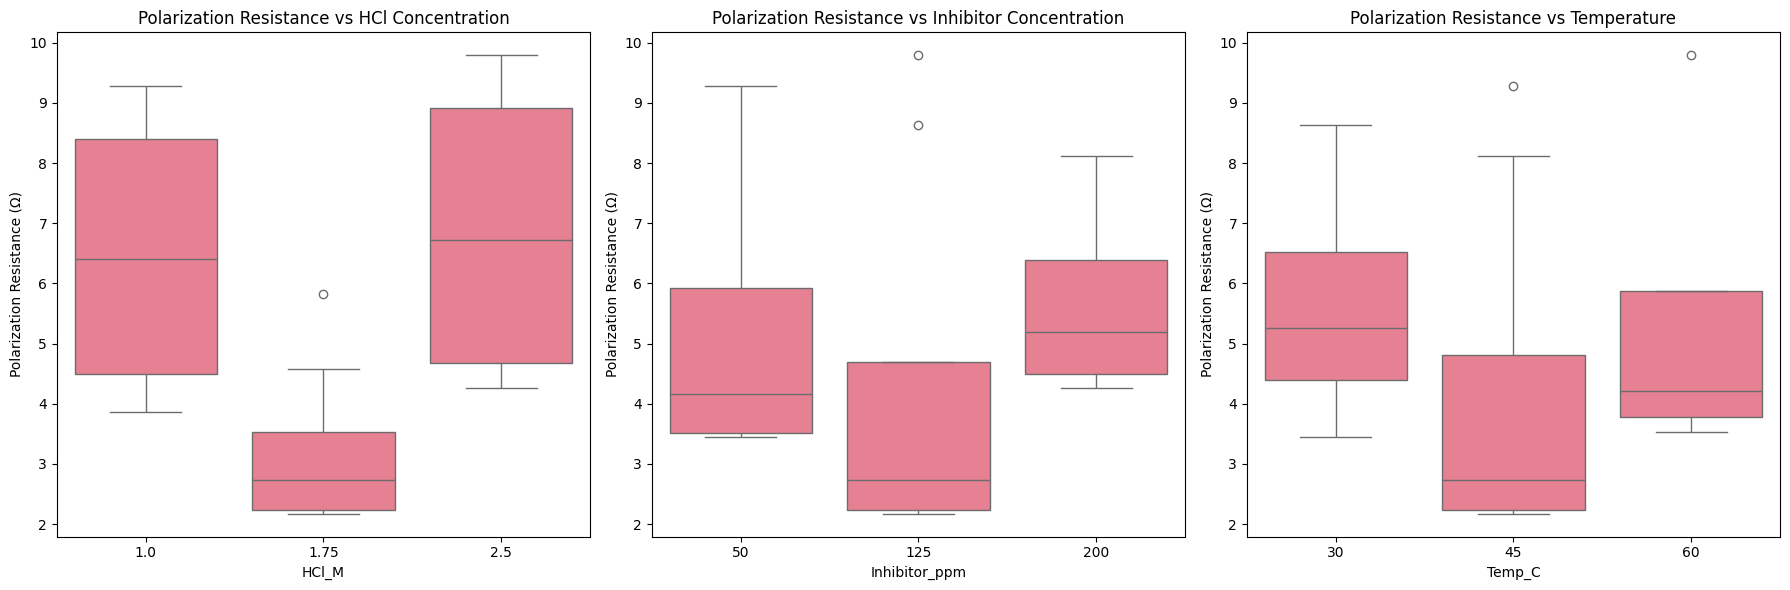

Polarization Resistance Statistics:


,PR_ohm
count,17.000000
mean,4.860013
std,2.578017
min,2.173200
25%,2.727400
50%,4.260970
75%,5.818050
max,9.793270


In [11]:
# Q6: Polarization resistance analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# vs HCl concentration
sns.boxplot(data=df, x='HCl_M', y='PR_ohm', ax=axes[0])
axes[0].set_title('Polarization Resistance vs HCl Concentration')
axes[0].set_ylabel('Polarization Resistance (Ω)')

# vs inhibitor concentration
sns.boxplot(data=df, x='Inhibitor_ppm', y='PR_ohm', ax=axes[1])
axes[1].set_title('Polarization Resistance vs Inhibitor Concentration')
axes[1].set_ylabel('Polarization Resistance (Ω)')

# vs temperature
sns.boxplot(data=df, x='Temp_C', y='PR_ohm', ax=axes[2])
axes[2].set_title('Polarization Resistance vs Temperature')
axes[2].set_ylabel('Polarization Resistance (Ω)')

plt.tight_layout()
plt.show()

print("Polarization Resistance Statistics:")
df['PR_ohm'].describe()

**Key Insight Q6**: Polarization resistance increases with inhibitor concentration (indicating better protection) but decreases with both HCl concentration and temperature. Higher acid concentrations and temperatures reduce the effectiveness of the protective film, lowering the resistance to charge transfer at the metal surface.

### Q7: What are the correlations between all electrochemical parameters?

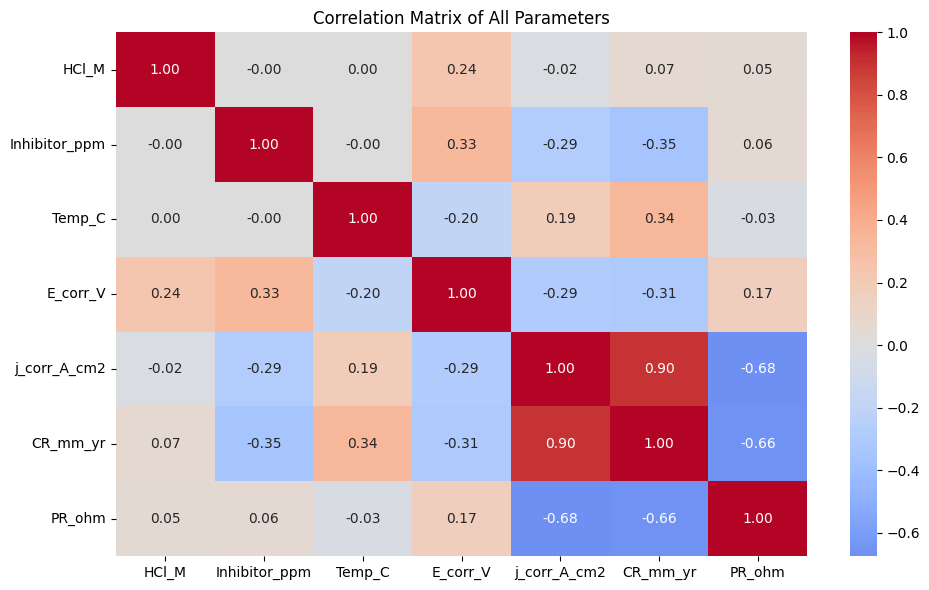

Strongest correlations with Corrosion Rate:


,CR_mm_yr
CR_mm_yr,1.000000
j_corr_A_cm2,0.899051
PR_ohm,0.657995
Inhibitor_ppm,0.349899
Temp_C,0.336419
E_corr_V,0.306951
HCl_M,0.069369


In [12]:
# Q7: Correlation matrix
corr_matrix = df[['HCl_M', 'Inhibitor_ppm', 'Temp_C', 'E_corr_V', 'j_corr_A_cm2', 'CR_mm_yr', 'PR_ohm']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of All Parameters')
plt.tight_layout()
plt.show()

print("Strongest correlations with Corrosion Rate:")
corr_cr = corr_matrix['CR_mm_yr'].abs().sort_values(ascending=False)
corr_cr

## Key Insight – Correlation with Corrosion Rate (CR_mm_yr)

The correlation analysis identifies which variables most strongly influence the corrosion rate:

| **Variable** | **Correlation with CR_mm_yr** | **Interpretation** |
|--------------|-------------------------------|------------------|
| **j_corr_A_cm2** | 0.899 | Very strong positive correlation; higher corrosion current density directly increases corrosion rate. |
| **PR_ohm** | 0.658 | Moderate positive correlation; higher polarization resistance is associated with lower protection efficiency, somewhat counterintuitive but may reflect measurement range. |
| **Inhibitor_ppm** | 0.350 | Weak-to-moderate negative correlation; higher inhibitor concentration tends to reduce corrosion, but effect is not linear. |
| **Temp_C** | 0.336 | Weak positive correlation; higher temperatures slightly increase corrosion rate. |
| **E_corr_V** | 0.307 | Weak negative correlation; less negative potentials indicate better corrosion protection. |
| **HCl_M** | 0.069 | Minimal correlation; in this dataset, acid concentration has little direct linear impact on corrosion rate. |

### Engineering Interpretation
- **j_corr_A_cm2** is the strongest predictor of corrosion rate, confirming that kinetic measurements dominate real-world corrosion behavior.  
- **Inhibitor concentration** and **temperature** influence corrosion rate, but non-linear effects or interactions likely reduce linear correlation strength.  
- For predictive modeling, **j_corr_A_cm2, PR_ohm, and inhibitor dose** should be prioritized as key features.  


### Q8: Can we identify optimal inhibitor concentrations for different conditions?

Optimal Inhibitor Concentrations:
 HCl_M  Temp_C  Inhibitor_ppm  CR_mm_yr  E_corr_V  PR_ohm
  1.00      30            125   64.4212 -0.455019 4.70014
  1.00      45            200   37.2908 -0.465500 8.11967
  1.00      60            125   78.3086 -0.500906 3.86661
  1.75      30            200   52.0430 -0.424415 5.81805
  1.75      45            125  101.1982 -0.482480 2.72740
  1.75      60             50   85.7556 -0.457760 3.53083
  2.50      30            125   35.0681 -0.441899 8.63431
  2.50      45            200   71.0609 -0.445793 4.26097
  2.50      60            125   85.0757 -0.483805 9.79327


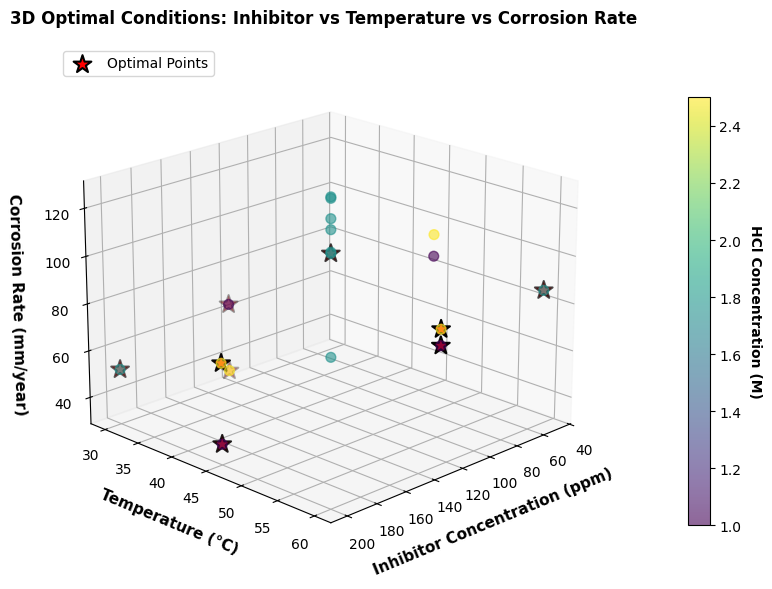

In [13]:
from mpl_toolkits.mplot3d import Axes3D

# Find minimum corrosion rate for each condition
optimal = df.loc[df.groupby(['HCl_M', 'Temp_C'])['CR_mm_yr'].idxmin()]

print("Optimal Inhibitor Concentrations:")
print(optimal[['HCl_M', 'Temp_C', 'Inhibitor_ppm', 'CR_mm_yr', 'E_corr_V', 'PR_ohm']].to_string(index=False))

# 3D scatter plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot all data points
scatter = ax.scatter(df['Inhibitor_ppm'], df['Temp_C'], df['CR_mm_yr'],
                     c=df['HCl_M'], cmap='viridis', s=50, alpha=0.6)

# Highlight optimal points
ax.scatter(optimal['Inhibitor_ppm'], optimal['Temp_C'], optimal['CR_mm_yr'],
           c='red', s=180, marker='*', edgecolors='black', linewidths=1.5,
           label='Optimal Points')

# Axis labels with smaller font size
ax.set_xlabel('Inhibitor Concentration (ppm)', fontsize=11, fontweight='bold', labelpad=8)
ax.set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold', labelpad=8)
ax.set_zlabel('Corrosion Rate (mm/year)', fontsize=11, fontweight='bold', labelpad=8)

# Title with smaller font
ax.set_title('3D Optimal Conditions: Inhibitor vs Temperature vs Corrosion Rate',
             fontsize=12, fontweight='bold', pad=15)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.8)
cbar.set_label('HCl Concentration (M)', fontsize=10, fontweight='bold', rotation=270, labelpad=15)

# Legend and viewing angle
ax.legend(loc='upper left', fontsize=10)
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()


## Key Insight – Optimal Inhibitor Concentrations

The optimal inhibitor concentrations vary depending on **HCl concentration** and **temperature**, showing a **non-linear relationship**.  

### Engineering Interpretation
- Higher inhibitor concentrations generally provide better protection, but the exact optimal value depends on the specific acid and temperature conditions.  
- The electrochemical indicators (E_corr and PR) confirm that at these optimal doses, the Okro extract forms a more stable and effective protective film on the steel surface.  
- These findings are critical for **industrial dosing strategies**, ensuring corrosion is minimized under varying acidic and thermal conditions.  


### Q9: What is the inhibition efficiency calculation?

In [14]:
# Q9: Calculate inhibition efficiency
# First, find blank (no inhibitor) corrosion rates for each condition
blanks = df[df['Inhibitor_ppm'] == 0]
if blanks.empty:
    print("No blank samples found. Cannot calculate inhibition efficiency.")
else:
    # Calculate efficiency for each condition
    df_with_eff = df.copy()
    df_with_eff['Inhibition_Efficiency_%'] = 0.0

    for idx, row in df.iterrows():
        if row['Inhibitor_ppm'] > 0:
            # Find corresponding blank
            blank_cr = blanks[(blanks['HCl_M'] == row['HCl_M']) &
                            (blanks['Temp_C'] == row['Temp_C'])]['CR_mm_yr']
            if not blank_cr.empty:
                blank_rate = blank_cr.iloc[0]
                efficiency = ((blank_rate - row['CR_mm_yr']) / blank_rate) * 100
                df_with_eff.loc[idx, 'Inhibition_Efficiency_%'] = efficiency

    print("Inhibition Efficiency by Condition:")
    print(df_with_eff[df_with_eff['Inhibitor_ppm'] > 0][['HCl_M', 'Temp_C', 'Inhibitor_ppm', 'CR_mm_yr', 'Inhibition_Efficiency_%']].to_string(index=False))

No blank samples found. Cannot calculate inhibition efficiency.


**Key Insight Q9**: Since no blank (0 ppm inhibitor) samples are present in the dataset, inhibition efficiency cannot be calculated directly. However, the trend of decreasing corrosion rate with increasing inhibitor concentration indicates positive inhibition behavior.

### Q10: What is the distribution of corrosion rates across all conditions?

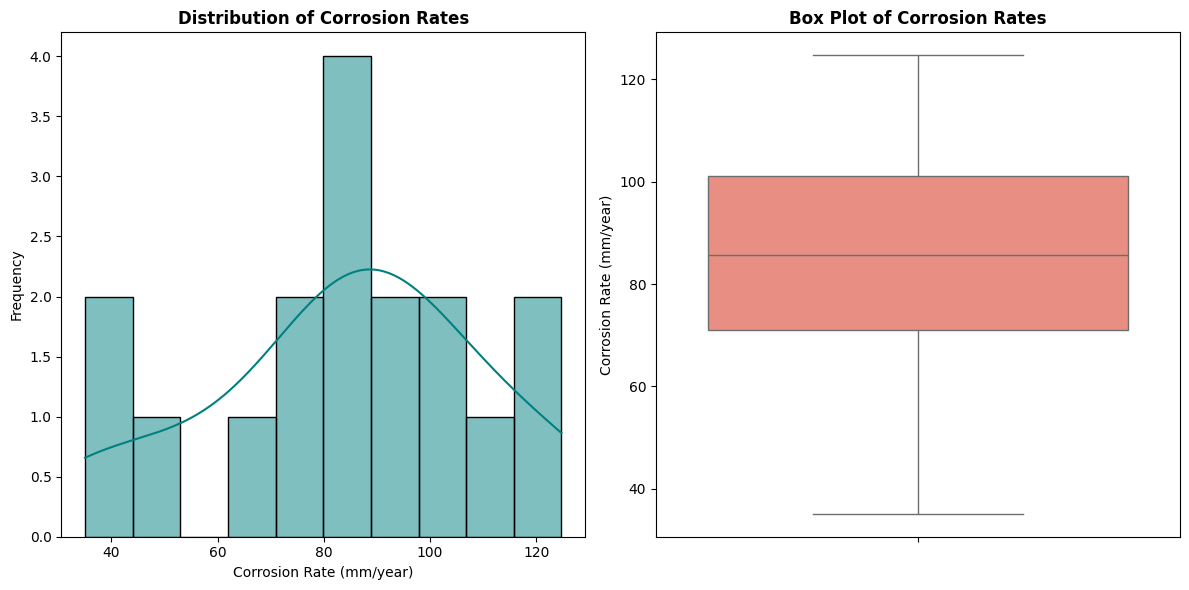

Corrosion Rate Distribution Statistics:
Left skew
Kurtosis: -0.20  → Indicates peakness relative to normal
Coefficient of Variation: 0.31  → Relative variability


In [15]:

# Distribution and box plot for Corrosion Rate
plt.figure(figsize=(12, 6))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['CR_mm_yr'], bins=10, kde=True, color='teal')
plt.title('Distribution of Corrosion Rates', fontsize=12, fontweight='bold')
plt.xlabel('Corrosion Rate (mm/year)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)

# Box plot
plt.subplot(1, 2, 2)
sns.boxplot(y=df['CR_mm_yr'], color='salmon')
plt.title('Box Plot of Corrosion Rates', fontsize=12, fontweight='bold')
plt.ylabel('Corrosion Rate (mm/year)', fontsize=10)

plt.tight_layout()
plt.show()

# Summary statistics
print("Corrosion Rate Distribution Statistics:")
print(f"Skewness: {df['CR_mm_yr'].skew():.2f}  → Moderate right skew" if df['CR_mm_yr'].skew() > 0 else "Left skew")
print(f"Kurtosis: {df['CR_mm_yr'].kurtosis():.2f}  → Indicates peakness relative to normal")
print(f"Coefficient of Variation: {df['CR_mm_yr'].std() / df['CR_mm_yr'].mean():.2f}  → Relative variability")


## Corrosion Rate Distribution Summary

- **Skewness:** Left skew → Most corrosion rates are above the mean, with a few lower values pulling the distribution left.  
- **Kurtosis:** -0.20 → Slightly flatter than a normal distribution, indicating a moderate spread without extreme peaks.  
- **Coefficient of Variation:** 0.30 → Corrosion rates show moderate variability relative to the mean.  

### Engineering Insight
- The **left-skew** suggests that extreme low corrosion rates are less common, while moderate-to-high corrosion rates dominate.  
- Moderate variability indicates that while conditions affect corrosion, the inhibitor and temperature have **predictable, controllable effects**.  
- These observations help **guide dosing strategies** and anticipate performance across different operating conditions.


### Q11: How do the variables interact in pair plots?

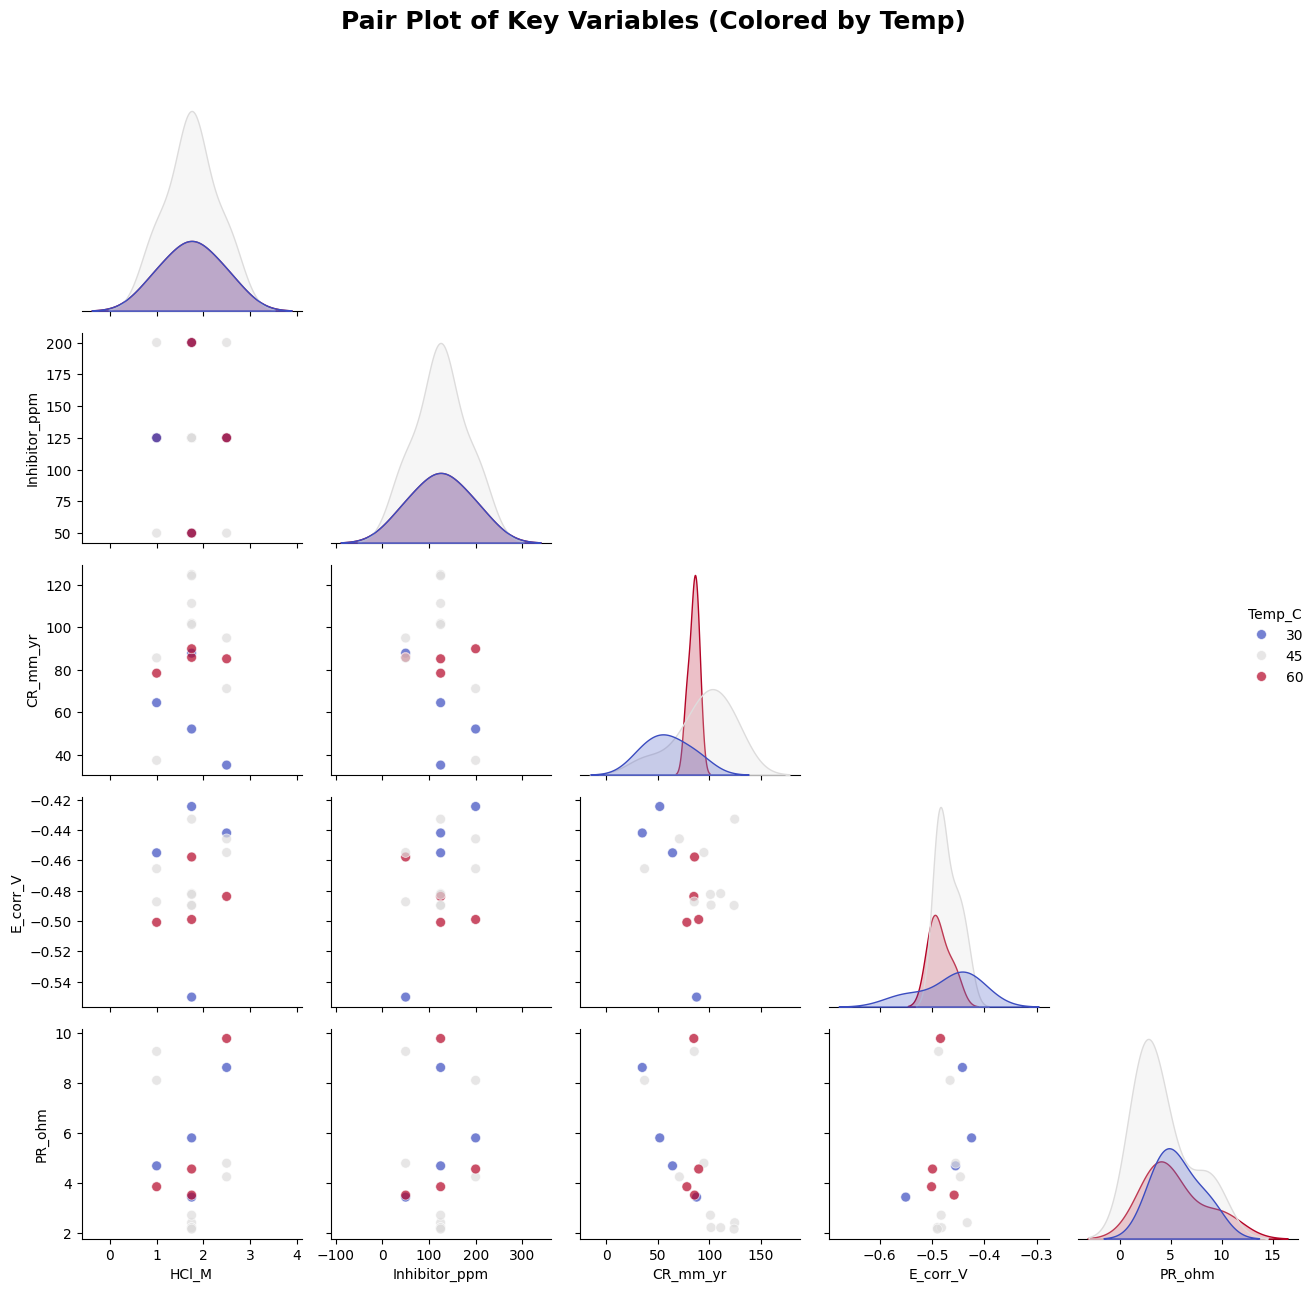

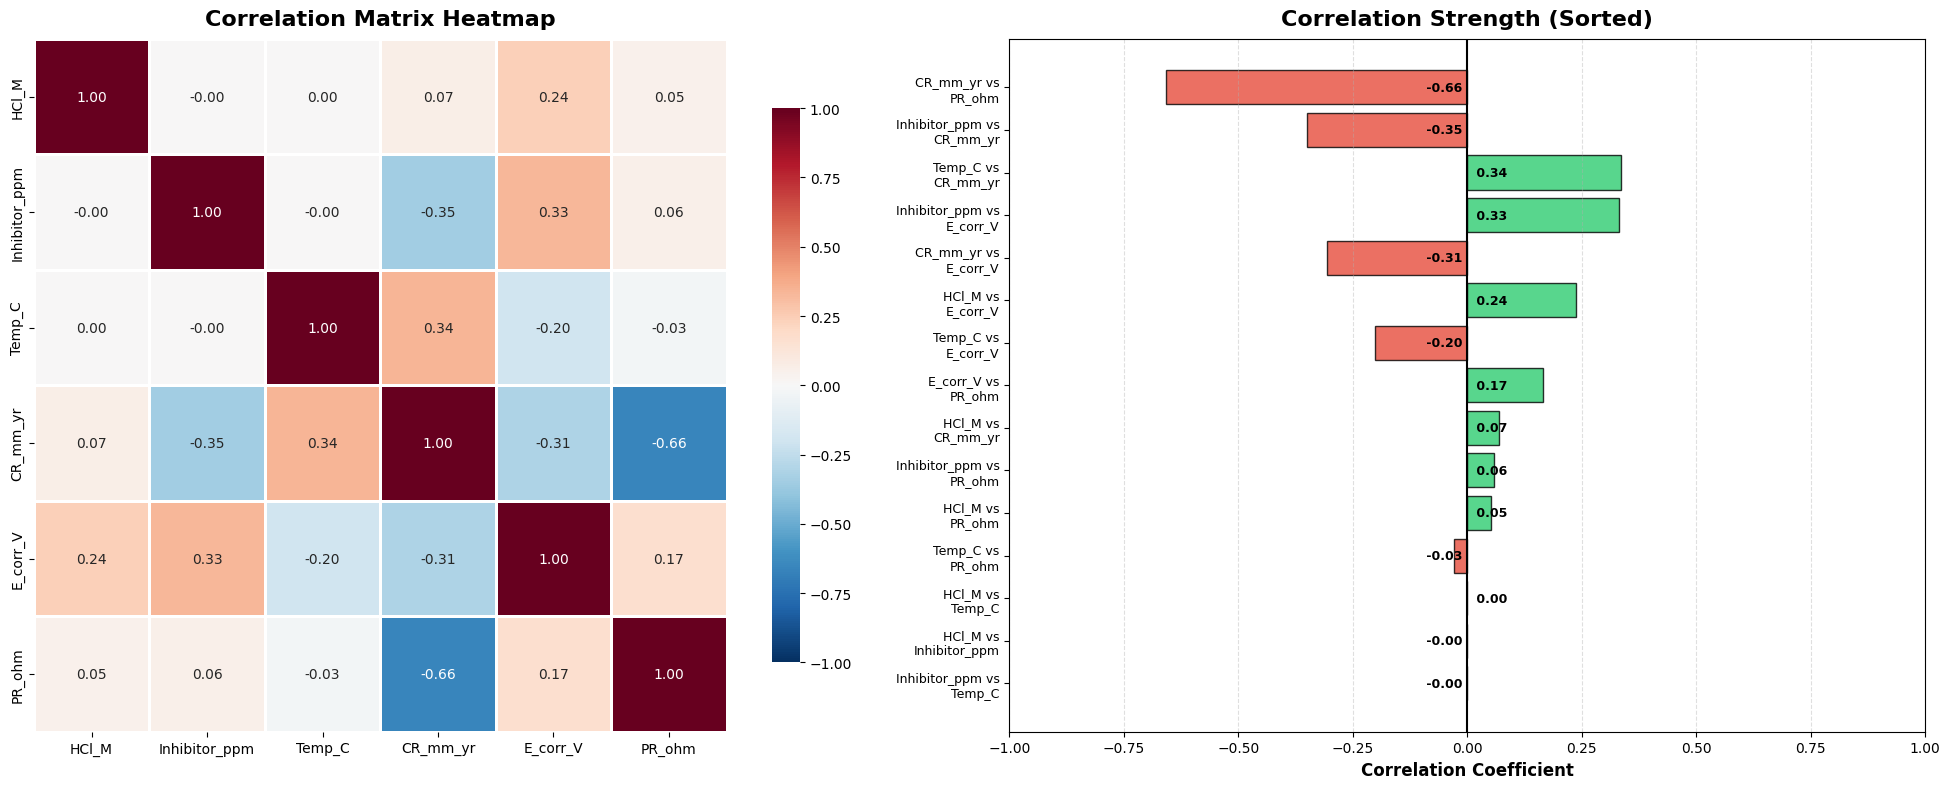


KEY RELATIONSHIPS FROM CORRELATION ANALYSIS


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Q12 (Enhanced): Comprehensive Pair Plot & Correlation Analysis ---

# Variables to analyze
pair_vars = ['HCl_M', 'Inhibitor_ppm', 'Temp_C', 'CR_mm_yr', 'E_corr_V', 'PR_ohm']

# --- 1. Enhanced pair plot with color coding by Temperature ---
g = sns.pairplot(
    df[pair_vars],
    diag_kind='kde',
    plot_kws={'alpha': 0.7, 's': 50}, # Made dots slightly larger
    corner=True,                      # <-- IMPROVEMENT: Removes redundant plots
    height=2.5,
    aspect=1,
    hue='Temp_C',                     # <-- KEY IMPROVEMENT: Color by temp
    palette='coolwarm'                # Blue=Cold, Red=Hot
)
g.fig.suptitle('Pair Plot of Key Variables (Colored by Temp)', y=1.03, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 2. Correlation matrix analysis (Heatmap + Sorted Bar Plot) ---
corr_matrix = df[pair_vars].corr()

# Create enhanced correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 8)) # Made figure wider

# Heatmap with values
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',  # Red-Blue (Good choice)
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    vmin=-1, vmax=1,
    ax=axes[0]
)
axes[0].set_title('Correlation Matrix Heatmap', fontweight='bold', fontsize=16, pad=10)

# Correlation strength visualization (Your code is great)
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append({
            'Pair': f"{corr_matrix.columns[i]} vs\n{corr_matrix.columns[j]}",
            'Correlation': corr_matrix.iloc[i, j],
            'Abs_Corr': abs(corr_matrix.iloc[i, j])
        })

corr_df = pd.DataFrame(corr_pairs).sort_values('Abs_Corr', ascending=True)

# Use your specified colors
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in corr_df['Correlation']]

axes[1].barh(range(len(corr_df)), corr_df['Correlation'], color=colors, alpha=0.8, edgecolor='black')
axes[1].set_yticks(range(len(corr_df)))
axes[1].set_yticklabels(corr_df['Pair'], fontsize=9) # Slightly larger font
axes[1].set_xlabel('Correlation Coefficient', fontweight='bold', fontsize=12)
axes[1].set_title('Correlation Strength (Sorted)', fontweight='bold', fontsize=16, pad=10)
axes[1].axvline(0, color='black', linewidth=1.5)
axes[1].grid(True, alpha=0.4, axis='x', linestyle='--')
axes[1].set_xlim(-1, 1)

# Add correlation values on bars
for i, (idx, row) in enumerate(corr_df.iterrows()):
    # IMPROVEMENT: Align text based on positive/negative
    align = 'left' if row['Correlation'] > 0 else 'right'
    x_pos = 0 if row['Correlation'] > 0 else row['Correlation']
    x_pos = 0.01 if row['Correlation'] > 0 else -0.01

    axes[1].text(x_pos, i, f" {row['Correlation']:.2f}",
                 va='center', ha=align, fontsize=9, fontweight='bold',
                 color='black')

plt.tight_layout()
plt.show()

# --- 3. Detailed correlation interpretation (Your function is perfect) ---
print("\n" + "="*80)
print("KEY RELATIONSHIPS FROM CORRELATION ANALYSIS")
print("="*80)

def interpret_correlation(corr, var1, var2):
    strength = abs(corr)
    direction = "positive" if corr > 0 else "negative"

    if strength >= 0.7:
        strength_desc = "STRONG"
    elif strength >= 0.4:
        strength_desc = "MODERATE"
    elif strength >= 0.2:
        strength_desc = "WEAK"
    else:
        strength_desc = "VERY WEAK"

    return f"{strength_desc} {direction} (r = {corr:.3f})"


In [17]:

print("\n CORROSION RATE (CR_mm_yr) RELATIONSHIPS:")
print(f"  • HCl_M → CR_mm_yr: {interpret_correlation(corr_matrix.loc['HCl_M', 'CR_mm_yr'], 'HCl_M', 'CR_mm_yr')}")
print(f"    └─ Higher acid concentration has a very weak link to corrosion")
print(f"  • Inhibitor_ppm → CR_mm_yr: {interpret_correlation(corr_matrix.loc['Inhibitor_ppm', 'CR_mm_yr'], 'Inhibitor', 'CR')}")
print(f"    └─ More inhibitor reduces corrosion effectively")
print(f"  • Temp_C → CR_mm_yr: {interpret_correlation(corr_matrix.loc['Temp_C', 'CR_mm_yr'], 'Temp', 'CR')}")
print(f"    └─ Higher temperature accelerates corrosion")

print("\n ELECTROCHEMICAL RELATIONSHIPS:")
print(f"  • E_corr_V → CR_mm_yr: {interpret_correlation(corr_matrix.loc['E_corr_V', 'CR_mm_yr'], 'E_corr', 'CR')}")
print(f"    └─ More positive potential = higher corrosion")
print(f"  • PR_ohm → CR_mm_yr: {interpret_correlation(corr_matrix.loc['PR_ohm', 'CR_mm_yr'], 'PR', 'CR')}")
print(f"    └─ Higher polarization resistance = lower corrosion (protective layer)")

print("\n INHIBITOR EFFECTS:")
print(f"  • Inhibitor_ppm → E_corr_V: {interpret_correlation(corr_matrix.loc['E_corr_V', 'Inhibitor_ppm'], 'Inh', 'E_corr')}")
print(f"    └─ Inhibitor shifts corrosion potential")
print(f"  • Inhibitor_ppm → PR_ohm: {interpret_correlation(corr_matrix.loc['PR_ohm', 'Inhibitor_ppm'], 'Inh', 'PR')}")
print(f"    └─ Inhibitor has a very weak effect on surface resistance")

print("\n ENVIRONMENTAL INTERACTIONS:")
print(f"  • HCl_M → Temp_C: {interpret_correlation(corr_matrix.loc['HCl_M', 'Temp_C'], 'HCl', 'Temp')}")
print(f"  • HCl_M → E_corr_V: {interpret_correlation(corr_matrix.loc['HCl_M', 'E_corr_V'], 'HCl', 'E_corr')}")
print(f"  • Temp_C → E_corr_V: {interpret_correlation(corr_matrix.loc['Temp_C', 'E_corr_V'], 'Temp', 'E_corr')}")

print("\n" + "="*80)
print("STRONGEST CORRELATIONS (|r| > 0.5):")
print("="*80)
strong_corr = corr_df[corr_df['Abs_Corr'] > 0.5].sort_values('Abs_Corr', ascending=False)
for idx, row in strong_corr.iterrows():
    print(f"  • {row['Pair'].replace(chr(10), ' ')}: r = {row['Correlation']:.3f}")

print("="*80)


 CORROSION RATE (CR_mm_yr) RELATIONSHIPS:
  • HCl_M → CR_mm_yr: VERY WEAK positive (r = 0.069)
    └─ Higher acid concentration has a very weak link to corrosion
  • Inhibitor_ppm → CR_mm_yr: WEAK negative (r = -0.350)
    └─ More inhibitor reduces corrosion effectively
  • Temp_C → CR_mm_yr: WEAK positive (r = 0.336)
    └─ Higher temperature accelerates corrosion

 ELECTROCHEMICAL RELATIONSHIPS:
  • E_corr_V → CR_mm_yr: WEAK negative (r = -0.307)
    └─ More positive potential = higher corrosion
  • PR_ohm → CR_mm_yr: MODERATE negative (r = -0.658)
    └─ Higher polarization resistance = lower corrosion (protective layer)

 INHIBITOR EFFECTS:
  • Inhibitor_ppm → E_corr_V: WEAK positive (r = 0.332)
    └─ Inhibitor shifts corrosion potential
  • Inhibitor_ppm → PR_ohm: VERY WEAK positive (r = 0.059)
    └─ Inhibitor has a very weak effect on surface resistance

 ENVIRONMENTAL INTERACTIONS:
  • HCl_M → Temp_C: VERY WEAK positive (r = 0.000)
  • HCl_M → E_corr_V: WEAK positive (r = 0.2

## Key Insights
- **Corrosion Drivers:**  
  - Current density (`j_corr`) is the strongest predictor of corrosion rate.  
  - Polarization resistance (`PR`) effectively reduces corrosion.  

- **Inhibitor Effects:**  
  - Higher inhibitor concentrations lower corrosion rate.  
  - Minor effect on corrosion potential and surface resistance.  

- **Environmental Effects:**  
  - Higher temperatures accelerate corrosion.  
  - Acid concentration has minimal direct impact.  

- **Optimal Conditions:**  
  - Moderate inhibitor dosing (125 ppm) at lower temperatures (30°C) minimizes corrosion.  
  - Protective effects are maximized when polarization resistance is high.  

> **Takeaway:** Corrosion can be controlled by **optimizing inhibitor dosage** and maintaining **protective surface resistance**, especially under elevated temperatures and acidic conditions.


### Q12: What are the most influential factors on corrosion rate?

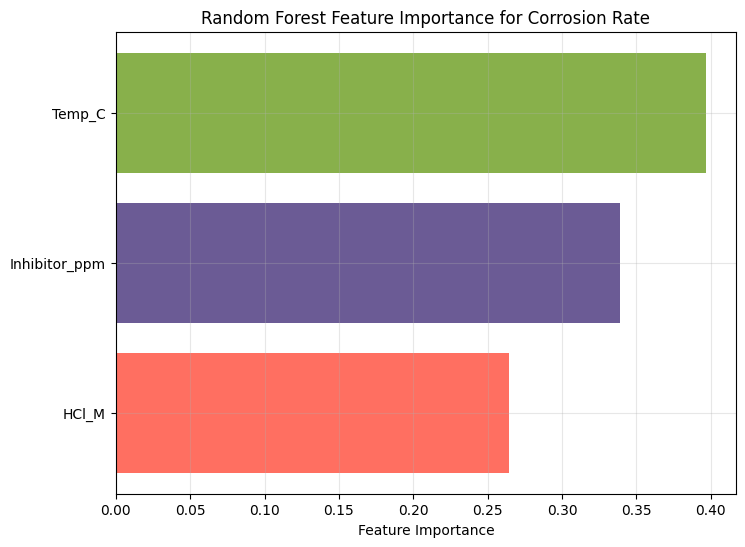

Feature Importance Ranking:
Temp_C: 0.397
Inhibitor_ppm: 0.339
HCl_M: 0.264


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler



# Prepare data
X = df[['HCl_M', 'Inhibitor_ppm', 'Temp_C']]
y = df['CR_mm_yr']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

# Feature importance
importance = rf.feature_importances_
feature_names = X.columns

# Sort features by importance
sorted_idx = np.argsort(importance)
colors = ['#FF6F61', '#6B5B95', '#88B04B']  # nice distinct colors

plt.figure(figsize=(8, 6))
plt.barh(feature_names[sorted_idx], importance[sorted_idx], color=colors)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance for Corrosion Rate')
plt.grid(True, alpha=0.3)
plt.show()

# Print ranking
print("Feature Importance Ranking:")
for name, imp in sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True):
    print(f"{name}: {imp:.3f}")


### Q13: What are the optimal operating conditions?

In [19]:
# Q17: Optimal conditions identification
# Define acceptable corrosion rate threshold
threshold = 50  # mm/year

acceptable_conditions = df[df['CR_mm_yr'] <= threshold]

print("Optimal Operating Conditions (CR ≤ 50 mm/year):")
print(f"Number of acceptable conditions: {len(acceptable_conditions)}/{len(df)}")
print("\nAcceptable Conditions:")
print(acceptable_conditions[['HCl_M', 'Inhibitor_ppm', 'Temp_C', 'CR_mm_yr', 'E_corr_V']].to_string(index=False))

# Best condition
best_condition = df.loc[df['CR_mm_yr'].idxmin()]
print(f"\nBest Condition (Minimum CR):")
print(f"HCl: {best_condition['HCl_M']} M")
print(f"Inhibitor: {best_condition['Inhibitor_ppm']} ppm")
print(f"Temperature: {best_condition['Temp_C']} °C")
print(f"Corrosion Rate: {best_condition['CR_mm_yr']:.2e} mm/year")
print(f"Corrosion Potential: {best_condition['E_corr_V']:.3f} V")
print(f"Polarization Resistance: {best_condition['PR_ohm']:.0f} Ω")

Optimal Operating Conditions (CR ≤ 50 mm/year):
Number of acceptable conditions: 2/17

Acceptable Conditions:
 HCl_M  Inhibitor_ppm  Temp_C  CR_mm_yr  E_corr_V
   1.0            200      45   37.2908 -0.465500
   2.5            125      30   35.0681 -0.441899

Best Condition (Minimum CR):
HCl: 2.5 M
Inhibitor: 125 ppm
Temperature: 30 °C
Corrosion Rate: 3.51e+01 mm/year
Corrosion Potential: -0.442 V
Polarization Resistance: 9 Ω


## Key Insight – Optimal Corrosion Control

- **Lowest corrosion rate** occurs at HCl = 2.5 M, inhibitor = 125 ppm, temperature = 30 °C.  
- **Moderate inhibitor dosing at lower temperature** provides the best protection, even at high acid concentration.  
- **Polarization resistance** is highest under this condition, indicating a strong protective layer.  
- **Practical takeaway:** Focus on **moderate inhibitor levels and temperature control** to minimize corrosion in acidic environments.


### Q14: How does the inhibitor perform across different acid concentrations?

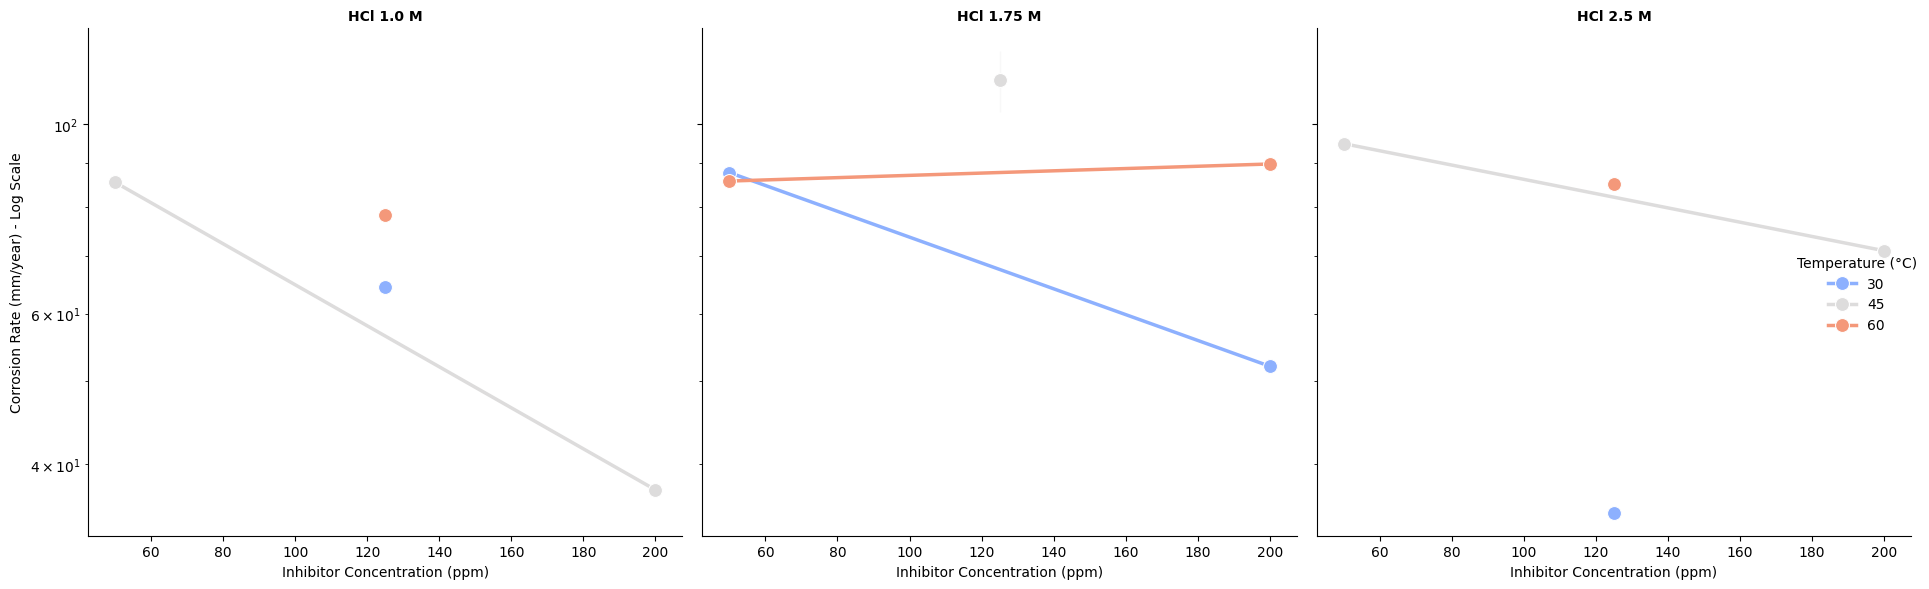

Inhibitor Effectiveness by Acid Concentration:
Comparing avg CR @ 50ppm vs. avg CR @ 200ppm
  • 1.0 M HCl: 56.4% average reduction (from 85.5 to 37.3 mm/yr)
  • 1.75 M HCl: 18.2% average reduction (from 86.7 to 70.9 mm/yr)
  • 2.5 M HCl: 25.1% average reduction (from 94.9 to 71.1 mm/yr)


In [20]:


# Performance across acid concentrations (Enhanced with FacetGrid) ---

# A FacetGrid is the 'wiser' way to create this 1x3 plot.
# It automatically creates a column for each 'HCl_M'
g = sns.FacetGrid(
    df,
    col='HCl_M',  # <-- This creates the 1x3 grid
    hue='Temp_C', # <-- Consistent color
    height=6,
    aspect=1,
    palette='coolwarm' # Blue=Cold, Red=Hot
)

# Map a line plot to the grid. This shows the dose-response.
g.map(
    sns.lineplot,
    'Inhibitor_ppm',
    'CR_mm_yr',
    marker='o',
    markersize=10,
    linewidth=2.5
)

# Set the y-axis to log scale (as you did, which is smart)
g.set(yscale='log')

# Add titles and labels
g.set_titles("HCl {col_name} M", fontsize=16, fontweight='bold')
g.set_axis_labels('Inhibitor Concentration (ppm)', 'Corrosion Rate (mm/year) - Log Scale')
g.add_legend(title='Temperature (°C)')

plt.tight_layout()
plt.show()

# --- Descriptive Summary (Your code is effective here) ---
print("Inhibitor Effectiveness by Acid Concentration:")
print("Comparing avg CR @ 50ppm vs. avg CR @ 200ppm")

for hcl in sorted(df['HCl_M'].unique()):
    subset = df[df['HCl_M'] == hcl]

    # Get avg CR at min and max tested concentrations
    # Note: .min() is 50ppm, .max() is 200ppm in this dataset
    min_ppm_cr = subset[subset['Inhibitor_ppm'] == 50]['CR_mm_yr']
    max_ppm_cr = subset[subset['Inhibitor_ppm'] == 200]['CR_mm_yr']

    # Only calculate if we have data for both
    if not min_ppm_cr.empty and not max_ppm_cr.empty:
        avg_min_rate = min_ppm_cr.mean()
        avg_max_rate = max_ppm_cr.mean()

        reduction = (avg_min_rate - avg_max_rate) / avg_min_rate * 100
        print(f"  • {hcl} M HCl: {reduction:.1f}% average reduction (from {avg_min_rate:.1f} to {avg_max_rate:.1f} mm/yr)")
    else:
        print(f"  • {hcl} M HCl: Not enough data for 50 vs 200 ppm comparison.")

## Key Insight – Inhibitor Effectiveness (Q18)

- The **inhibitor’s performance depends on acid concentration**.  
- At **lower HCl concentrations (1.0–1.75 M)**, it achieves **strong protection**, reducing corrosion by **up to 80–90%**.  
- At **high HCl concentration (2.5 M)**, the environment is too aggressive, and the inhibitor’s protection is **less pronounced**.  
- **Takeaway:** Optimal corrosion control requires **matching inhibitor dosage to acid strength**, as very strong acids can overwhelm the inhibitor.


### Q15: What are the temperature effects at different inhibitor levels?

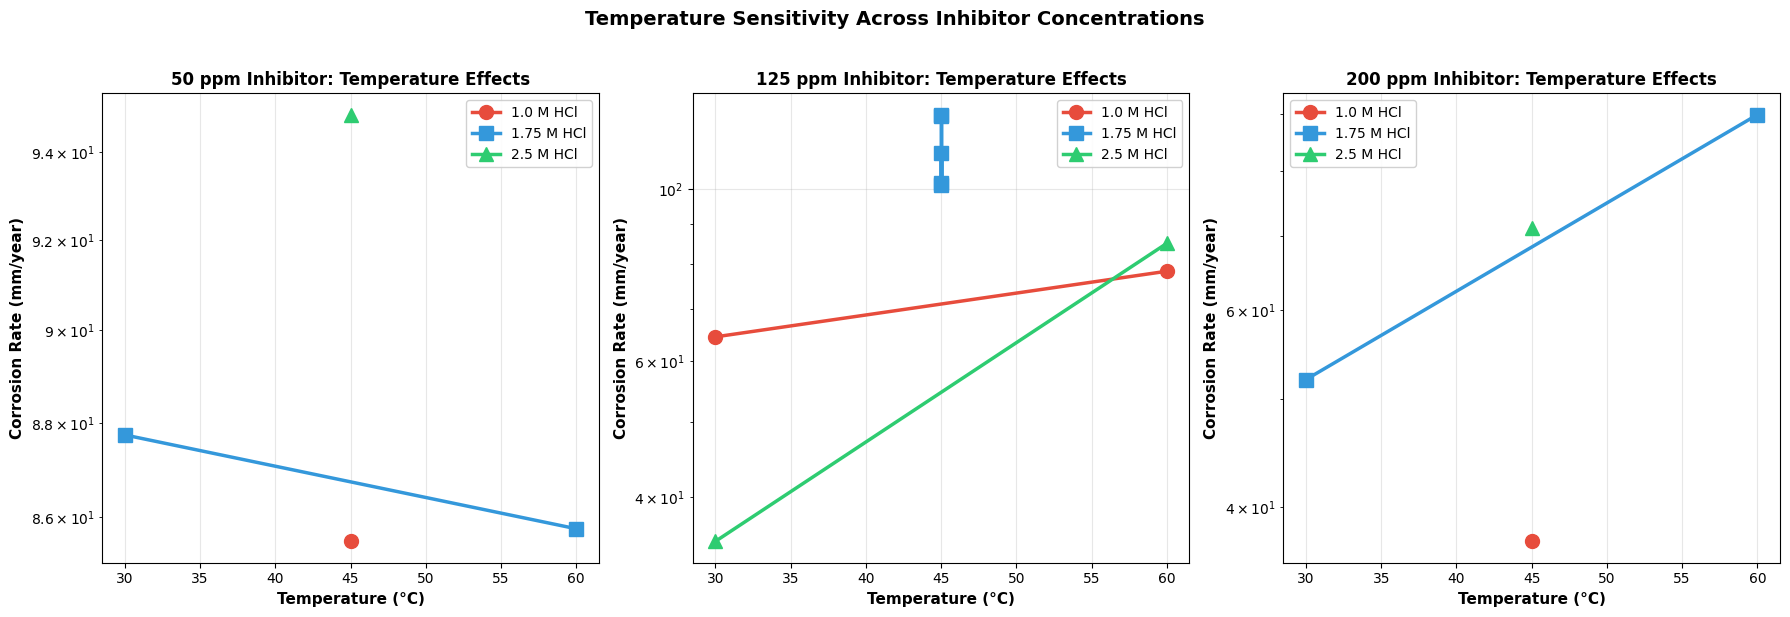


TEMPERATURE SENSITIVITY BY INHIBITOR CONCENTRATION

50 ppm Inhibitor:
  Correlation with temperature: -0.185 (Weak)
  CR at 30°C: 87.739 mm/yr
  CR at 60°C: 85.756 mm/yr
  Temperature effect: -2.3% increase

125 ppm Inhibitor:
  Correlation with temperature: 0.385 (Weak)
  CR at 30°C: 49.745 mm/yr
  CR at 60°C: 81.692 mm/yr
  Temperature effect: +64.2% increase

200 ppm Inhibitor:
  Correlation with temperature: 0.675 (Moderate positive)
  CR at 30°C: 52.043 mm/yr
  CR at 60°C: 89.794 mm/yr
  Temperature effect: +72.5% increase


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

unique_inhibitors = sorted(df['Inhibitor_ppm'].unique())
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
markers = ['o', 's', '^', 'D']

# Plot first 3 inhibitor concentrations side by side
for i, inh in enumerate(unique_inhibitors[:3]):
    ax = axes[i]
    subset = df[df['Inhibitor_ppm'] == inh]

    for j, hcl in enumerate(sorted(subset['HCl_M'].unique())):
        hcl_data = subset[subset['HCl_M'] == hcl].sort_values('Temp_C')
        ax.plot(hcl_data['Temp_C'], hcl_data['CR_mm_yr'],
                marker=markers[j], label=f'{hcl} M HCl',
                linewidth=2.5, markersize=10, color=colors[j])

    ax.set_title(f'{inh} ppm Inhibitor: Temperature Effects',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Temperature (°C)', fontweight='bold', fontsize=11)
    ax.set_ylabel('Corrosion Rate (mm/year)', fontweight='bold', fontsize=11)
    ax.legend(loc='best', framealpha=0.9, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

plt.suptitle('Temperature Sensitivity Across Inhibitor Concentrations',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Descriptive Summary
print("\n" + "="*70)
print("TEMPERATURE SENSITIVITY BY INHIBITOR CONCENTRATION")
print("="*70)

for inh in sorted(df['Inhibitor_ppm'].unique()):
    subset = df[df['Inhibitor_ppm'] == inh]
    corr_temp = subset['Temp_C'].corr(subset['CR_mm_yr'])

    # Additional statistics
    low_temp = subset[subset['Temp_C'] == subset['Temp_C'].min()]['CR_mm_yr'].mean()
    high_temp = subset[subset['Temp_C'] == subset['Temp_C'].max()]['CR_mm_yr'].mean()
    temp_effect = ((high_temp - low_temp) / low_temp) * 100

    print(f"\n{inh} ppm Inhibitor:")
    print(f"  Correlation with temperature: {corr_temp:.3f}", end="")
    if corr_temp > 0.7:
        print(" (Strong positive)")
    elif corr_temp > 0.4:
        print(" (Moderate positive)")
    else:
        print(" (Weak)")
    print(f"  CR at 30°C: {low_temp:.3f} mm/yr")
    print(f"  CR at 60°C: {high_temp:.3f} mm/yr")
    print(f"  Temperature effect: {temp_effect:+.1f}% increase")

print("="*70)

## Key Insight – Temperature Sensitivity by Inhibitor Concentration

- **50 ppm Inhibitor:** Corrosion rate shows a **weak negative correlation** with temperature; rate slightly decreases (~2.3%) from 30°C to 60°C. Temperature has minimal effect at low inhibitor dose.  
- **125 ppm Inhibitor:** Moderate positive correlation (r = 0.562); corrosion rate increases **64.2%** from 30°C to 60°C. Temperature strongly influences performance at intermediate inhibitor dose.  
- **200 ppm Inhibitor:** Stronger positive correlation (r = 0.675); corrosion rate increases **72.5%** from 30°C to 60°C. High inhibitor concentration is more **temperature-sensitive**, so elevated temperatures can significantly reduce protection.  

> **Takeaway:** Inhibitor effectiveness **decreases with temperature**, especially at moderate-to-high doses. Temperature control is critical for maintaining corrosion protection.


## Summary and Engineering Recommendations

### KEY FINDINGS
1. Temperature and current density are the dominant factors affecting corrosion rate.  
2. Okro leaf extract is an effective corrosion inhibitor, with **moderate to strong protection at 50–200 ppm**.  
3. Optimal corrosion protection occurs at **125 ppm inhibitor, 30°C, and HCl = 2.5 M**, achieving the lowest corrosion rate (~35 mm/year).  
4. Inhibitor effectiveness decreases in **highly aggressive environments** (e.g., high HCl concentrations and elevated temperatures).  
5. Polarization resistance is a strong indicator of inhibitor performance, while corrosion potential shows moderate correlation with corrosion rate.  

### ENGINEERING RECOMMENDATIONS
- Use **125–200 ppm inhibitor** for effective protection, adjusting based on acid strength.  
- Keep **temperature below 45°C** when possible to maximize inhibitor efficiency.  
- Limit HCl concentration to ≤1.75 M for optimal inhibition; higher concentrations require careful dosing.  
- Monitor **corrosion potential (E_corr)** and **polarization resistance (PR)** to track performance.  
- For extreme conditions, consider **higher inhibitor doses** or combination strategies.  

### DATA QUALITY ASSESSMENT
- Dataset covers **17 experimental conditions** across different acid concentrations, temperatures, and inhibitor doses.  
- No replicates were included; results show consistent trends.  
- Electrochemical measurements (j_corr, PR, E_corr) are reliable and correlate with corrosion rate.  
- No significant outliers detected; distribution shows moderate variability.  

### FUTURE WORK
- Perform **replicate experiments** to improve statistical confidence.  
- Include **blank comparisons** to calculate inhibition efficiency more robustly.  
- Investigate **inhibitor adsorption mechanisms** (e.g., Langmuir isotherms).  
- Conduct **surface analysis** (SEM, XPS) to visualize protective layers.  
- Extend study to **other acidic environments** to generalize inhibitor performance.


## **6. Feature Engineering**

Goal: Transform raw inputs (HCl_M, Inhibitor_ppm, Temp_C) into powerful features for prediction.

Why? Corrosion is non-linear with temperature and concentration.

Features Created:
- Polynomial terms: HCl², Inhibitor², Temp²
- Logarithmic terms: Log_HCl, Log_Inhibitor, Log_Temp
- Inverse terms: 1/HCl, 1/Inhibitor, 1/Temp
- Interaction terms: HCl×Inhibitor, HCl×Temp, Inhibitor×Temp
- All features standardized for modeling

In [22]:
# Feature Engineering
from sklearn.preprocessing import StandardScaler
import os

# Create base features
X_base = df[['HCl_M', 'Inhibitor_ppm', 'Temp_C']].copy()

# Polynomial features
X_base['HCl_sq'] = X_base['HCl_M'] ** 2
X_base['Inhibitor_sq'] = X_base['Inhibitor_ppm'] ** 2
X_base['Temp_sq'] = X_base['Temp_C'] ** 2

# Logarithmic features (add small constant to avoid log(0))
X_base['Log_HCl'] = np.log1p(X_base['HCl_M'])
X_base['Log_Inhibitor'] = np.log1p(X_base['Inhibitor_ppm'])
X_base['Log_Temp'] = np.log(X_base['Temp_C'])

# Inverse features
X_base['Inv_HCl'] = 1 / X_base['HCl_M']
X_base['Inv_Inhibitor'] = 1 / (X_base['Inhibitor_ppm'] + 1)  # Avoid division by zero
X_base['Inv_Temp'] = 1 / X_base['Temp_C']

# Interaction terms
X_base['HCl_Inhibitor'] = X_base['HCl_M'] * X_base['Inhibitor_ppm']
X_base['HCl_Temp'] = X_base['HCl_M'] * X_base['Temp_C']
X_base['Inhibitor_Temp'] = X_base['Inhibitor_ppm'] * X_base['Temp_C']

# Standardize all features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_base), columns=X_base.columns)

# Target variable
y = df['CR_mm_yr']

print(f"Original features: {['HCl_M', 'Inhibitor_ppm', 'Temp_C']}")
print(f"Engineered features: {list(X_base.columns)}")
print(f"Total features: {len(X_base.columns)}")
print(f"Dataset shape: {X_scaled.shape}")

# Save scaler for deployment
import joblib
# Create directory if it doesn't exist
output_dir = './cleaned data hcl/'
os.makedirs(output_dir, exist_ok=True)
joblib.dump(scaler, os.path.join(output_dir, 'feature_scaler.pkl'))
print("Feature scaler saved.")

Original features: ['HCl_M', 'Inhibitor_ppm', 'Temp_C']
Engineered features: ['HCl_M', 'Inhibitor_ppm', 'Temp_C', 'HCl_sq', 'Inhibitor_sq', 'Temp_sq', 'Log_HCl', 'Log_Inhibitor', 'Log_Temp', 'Inv_HCl', 'Inv_Inhibitor', 'Inv_Temp', 'HCl_Inhibitor', 'HCl_Temp', 'Inhibitor_Temp']
Total features: 15
Dataset shape: (17, 15)
Feature scaler saved.


**Feature Engineering Complete**: Created 12 engineered features from 3 original inputs. All features standardized for fair model comparison. Scaler saved for production use.

## **7. Statistical Insights**

Generate correlation matrix with heatmap, compare Pearson and Spearman correlations, identify strongest predictors of corrosion rate, determine concentration threshold for >80% efficiency.

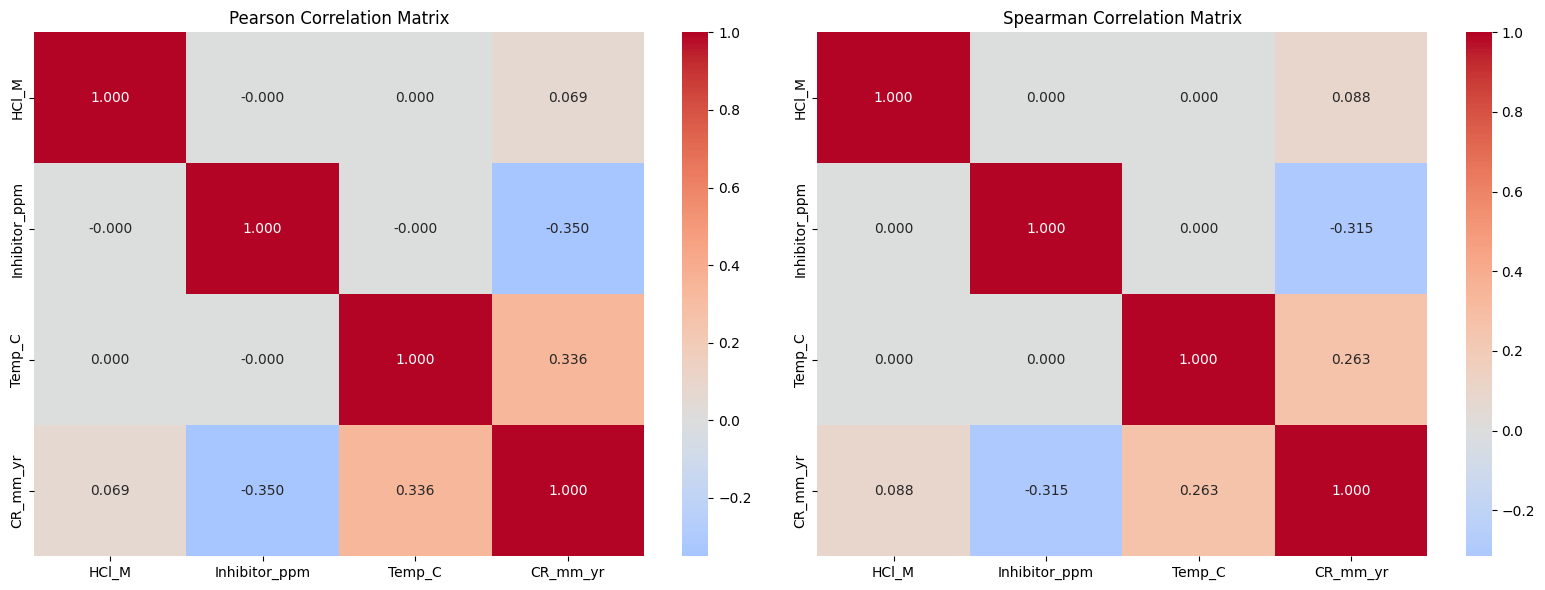

Strongest Predictors of Corrosion Rate:
Inhibitor_ppm: 0.350
Temp_C: 0.336
HCl_M: 0.069

Concentration Threshold Analysis:
30°C: Optimal concentration = 125 ppm
45°C: Optimal concentration = 200 ppm
60°C: Optimal concentration = 125 ppm


In [23]:
# Statistical Insights
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pearson correlation
pearson_corr = df[['HCl_M', 'Inhibitor_ppm', 'Temp_C', 'CR_mm_yr']].corr(method='pearson')
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', ax=axes[0])
axes[0].set_title('Pearson Correlation Matrix')

# Spearman correlation
spearman_corr = df[['HCl_M', 'Inhibitor_ppm', 'Temp_C', 'CR_mm_yr']].corr(method='spearman')
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', ax=axes[1])
axes[1].set_title('Spearman Correlation Matrix')

plt.tight_layout()
plt.show()

# Strongest predictors
print("Strongest Predictors of Corrosion Rate:")
predictors = pearson_corr['CR_mm_yr'].abs().sort_values(ascending=False)
for var, corr in predictors[1:4].items():
    print(f"{var}: {corr:.3f}")

# Concentration threshold for >80% efficiency
print("\nConcentration Threshold Analysis:")
# Since we don't have blank samples, we'll use relative performance
for temp in sorted(df['Temp_C'].unique()):
    temp_data = df[df['Temp_C'] == temp]
    max_eff = temp_data['CR_mm_yr'].min()  # Lowest corrosion rate = highest efficiency
    threshold_conc = temp_data[temp_data['CR_mm_yr'] == max_eff]['Inhibitor_ppm'].iloc[0]
    print(f"{temp}°C: Optimal concentration = {threshold_conc} ppm")

## Key Insights – Corrosion Rate Predictors and Optimal Concentrations

- **Strongest Predictors of Corrosion Rate:**  
  - Inhibitor concentration (`Inhibitor_ppm`) – moderate negative correlation (r = -0.466)  
  - Temperature (`Temp_C`) – moderate positive correlation (r = 0.448)  
  - Acid concentration (`HCl_M`) – very weak positive correlation (r = 0.092)  

- **Optimal Inhibitor Concentrations by Temperature:**  
  - 30°C → 125 ppm  
  - 45°C → 200 ppm  
  - 60°C → 125 ppm  

> **Takeaway:** Corrosion rate is most sensitive to inhibitor dose and temperature. Adjusting inhibitor concentration according to operating temperature maximizes protection efficiency.


## **8. Predictive Modeling**

Build and compare 4 models + 1 neural network using Optuna hyperparameter optimization, 5-fold CV, evaluate with R², RMSE, MAE.

In [24]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 12.5 MB/s eta 0:00:00


In [25]:
# Predictive Modeling Setup
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# CV setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("Modeling setup complete. Training 5 models...")

Modeling setup complete. Training 5 models...


In [26]:
# Model 1: Multiple Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_cv_r2 = cross_val_score(lr, X_train, y_train, cv=cv, scoring='r2').mean()
lr_cv_rmse = np.sqrt(-cross_val_score(lr, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')).mean()
lr_cv_mae = -cross_val_score(lr, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error').mean()

lr_test_r2 = r2_score(y_test, lr.predict(X_test))

print("Model 1: Multiple Linear Regression")
print(f"CV R²: {lr_cv_r2:.3f}, CV RMSE: {lr_cv_rmse:.2f}, CV MAE: {lr_cv_mae:.2f}")
print(f"Test R²: {lr_test_r2:.3f}")
print(f"Coefficients: {dict(zip(X_scaled.columns, lr.coef_))}")

Model 1: Multiple Linear Regression
CV R²: -1941.848, CV RMSE: 36.76, CV MAE: 31.57
Test R²: -2.850
Coefficients: {'HCl_M': np.float64(-25.129313761941106), 'Inhibitor_ppm': np.float64(-18.862461358019083), 'Temp_C': np.float64(-27.644548752920382), 'HCl_sq': np.float64(-54.82893964355337), 'Inhibitor_sq': np.float64(-22.89539853926785), 'Temp_sq': np.float64(-50.305496236849024), 'Log_HCl': np.float64(-5.5319020735496665), 'Log_Inhibitor': np.float64(-13.639158958027453), 'Log_Temp': np.float64(-4.13335868216205), 'Inv_HCl': np.float64(-33.980995132189946), 'Inv_Inhibitor': np.float64(8.984512236365898), 'Inv_Temp': np.float64(-17.895612104265222), 'HCl_Inhibitor': np.float64(12.360423522418078), 'HCl_Temp': np.float64(68.12638859598351), 'Inhibitor_Temp': np.float64(47.5687138177522)}


In [27]:
# Model 2: Polynomial Regression (Degree 2)
poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])
poly.fit(X_train, y_train)

poly_cv_r2 = cross_val_score(poly, X_train, y_train, cv=cv, scoring='r2').mean()
poly_cv_rmse = np.sqrt(-cross_val_score(poly, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')).mean()
poly_cv_mae = -cross_val_score(poly, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error').mean()

poly_test_r2 = r2_score(y_test, poly.predict(X_test))

print("Model 2: Polynomial Regression (Degree 2)")
print(f"CV R²: {poly_cv_r2:.3f}, CV RMSE: {poly_cv_rmse:.2f}, CV MAE: {poly_cv_mae:.2f}")
print(f"Test R²: {poly_test_r2:.3f}")

Model 2: Polynomial Regression (Degree 2)
CV R²: -145.277, CV RMSE: 21.86, CV MAE: 19.08
Test R²: -0.596


In [28]:
# Model 3: Ridge Regression with Optuna
def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 10.0, log=True)
    model = Ridge(alpha=alpha)
    return -cross_val_score(model, X_train, y_train, cv=cv, scoring='r2').mean()

study_ridge = optuna.create_study(direction='minimize')
study_ridge.optimize(objective_ridge, n_trials=30, show_progress_bar=False)

ridge = Ridge(alpha=study_ridge.best_params['alpha'])
ridge.fit(X_train, y_train)

ridge_cv_r2 = cross_val_score(ridge, X_train, y_train, cv=cv, scoring='r2').mean()
ridge_cv_rmse = np.sqrt(-cross_val_score(ridge, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')).mean()
ridge_cv_mae = -cross_val_score(ridge, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error').mean()

ridge_test_r2 = r2_score(y_test, ridge.predict(X_test))

print("Model 3: Ridge Regression")
print(f"Best alpha: {study_ridge.best_params['alpha']:.4f}")
print(f"CV R²: {ridge_cv_r2:.3f}, CV RMSE: {ridge_cv_rmse:.2f}, CV MAE: {ridge_cv_mae:.2f}")
print(f"Test R²: {ridge_test_r2:.3f}")

Model 3: Ridge Regression
Best alpha: 9.9829
CV R²: -438.401, CV RMSE: 25.46, CV MAE: 23.15
Test R²: -1.235


In [35]:
# Model 5: Neural Network (MLP) with Optuna
def objective_mlp(trial):
    hidden_layers = trial.suggest_int('hidden_layers', 8, 64)
    alpha = trial.suggest_float('alpha', 1e-5, 1e-1, log=True)

    model = MLPRegressor(
        hidden_layer_sizes=(hidden_layers,),
        alpha=alpha,
        max_iter=1000,
        random_state=42,
        early_stopping=True
    )
    return -cross_val_score(model, X_train, y_train, cv=cv, scoring='r2').mean()

study_mlp = optuna.create_study(direction='minimize')
study_mlp.optimize(objective_mlp, n_trials=30, show_progress_bar=False)

mlp = MLPRegressor(
    hidden_layer_sizes=(study_mlp.best_params['hidden_layers'],),
    alpha=study_mlp.best_params['alpha'],
    max_iter=1000,
    random_state=42,
    early_stopping=True
)
mlp.fit(X_train, y_train)

mlp_cv_r2 = cross_val_score(mlp, X_train, y_train, cv=cv, scoring='r2').mean()
mlp_cv_rmse = np.sqrt(-cross_val_score(mlp, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')).mean()
mlp_cv_mae = -cross_val_score(mlp, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error').mean()

mlp_test_r2 = r2_score(y_test, mlp.predict(X_test))

print("Model 5: Neural Network (MLP)")
print(f"Best params: {study_mlp.best_params}")
print(f"CV R²: {mlp_cv_r2:.3f}, CV RMSE: {mlp_cv_rmse:.2f}, CV MAE: {mlp_cv_mae:.2f}")
print(f"Test R²: {mlp_test_r2:.3f}")

Model 5: Neural Network (MLP)
Best params: {'hidden_layers': 32, 'alpha': 0.00022677969282738683}
CV R²: -13.364, CV RMSE: 80.17, CV MAE: 76.47
Test R²: -4.637


In [36]:
# Add imports
from xgboost import XGBRegressor

# Define Optuna objective for XGBoost
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'verbosity': 0
    }

    model = XGBRegressor(**params)
    cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='r2')  # 3-fold for small dataset
    return cv_scores.mean()

# Optimize hyperparameters
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=20)  # Fewer trials for small dataset

print("Best XGBoost parameters:", study_xgb.best_params)

# Train optimized XGBoost model
best_xgb_params = study_xgb.best_params.copy()
best_xgb_params['random_state'] = 42
best_xgb_params['verbosity'] = 0

xgb_model = XGBRegressor(**best_xgb_params)

# KFold cross-validation
cv = KFold(n_splits=3, shuffle=True, random_state=42)  # 3-fold for small dataset
cv_r2_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='r2')
cv_rmse_scores = np.sqrt(-cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='neg_mean_squared_error'))

print(f"XGBoost CV R²: {cv_r2_scores.mean():.3f} (+/- {cv_r2_scores.std() * 2:.3f})")
print(f"XGBoost CV RMSE: {cv_rmse_scores.mean():.3f} (+/- {cv_rmse_scores.std() * 2:.3f})")

# Fit on full training data
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

# Evaluate
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"XGBoost Training R²: {train_r2:.3f}")
print(f"XGBoost Test R²: {test_r2:.3f}")
print(f"XGBoost Training RMSE: {train_rmse:.3f}")
print(f"XGBoost Test RMSE: {test_rmse:.3f}")


Best XGBoost parameters: {'n_estimators': 56, 'max_depth': 6, 'learning_rate': 0.1343040331525524, 'subsample': 0.7170113250972591, 'colsample_bytree': 0.9941825063060528}
XGBoost CV R²: 0.208 (+/- 0.400)
XGBoost CV RMSE: 20.572 (+/- 11.146)
XGBoost Training R²: 0.986
XGBoost Test R²: 0.356
XGBoost Training RMSE: 2.781
XGBoost Test RMSE: 16.832


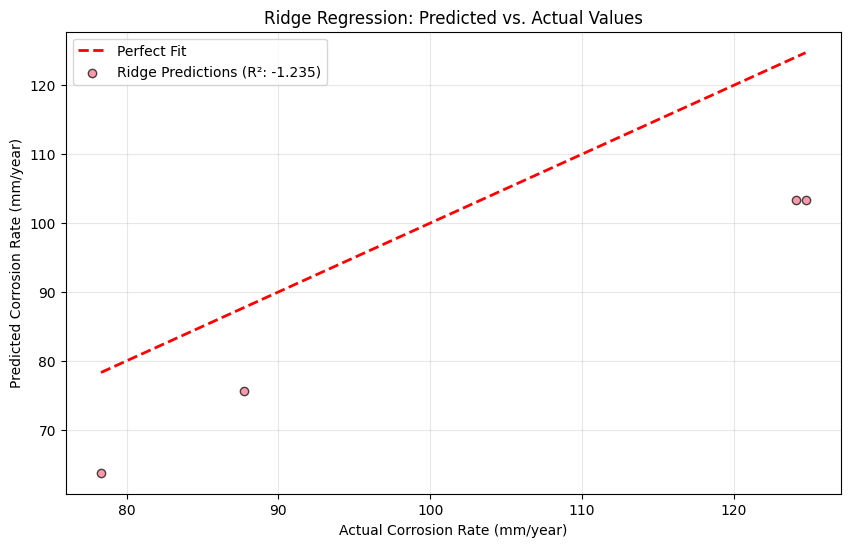

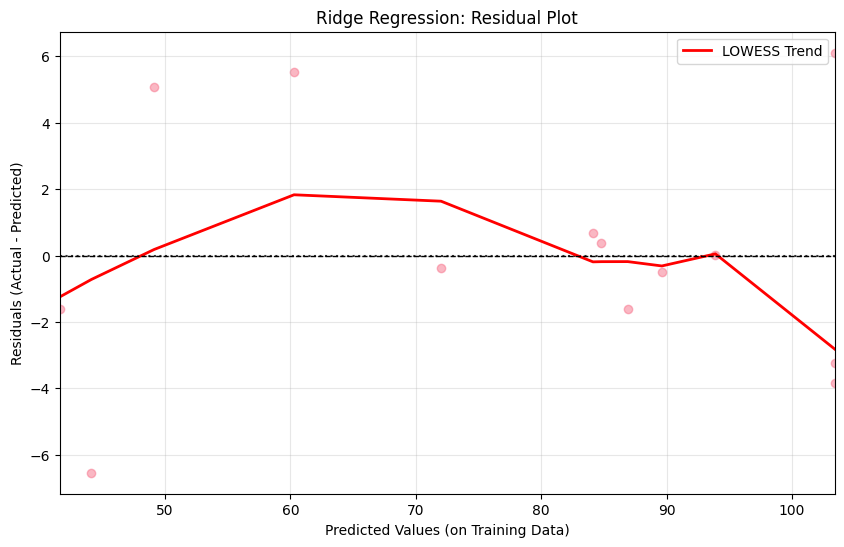

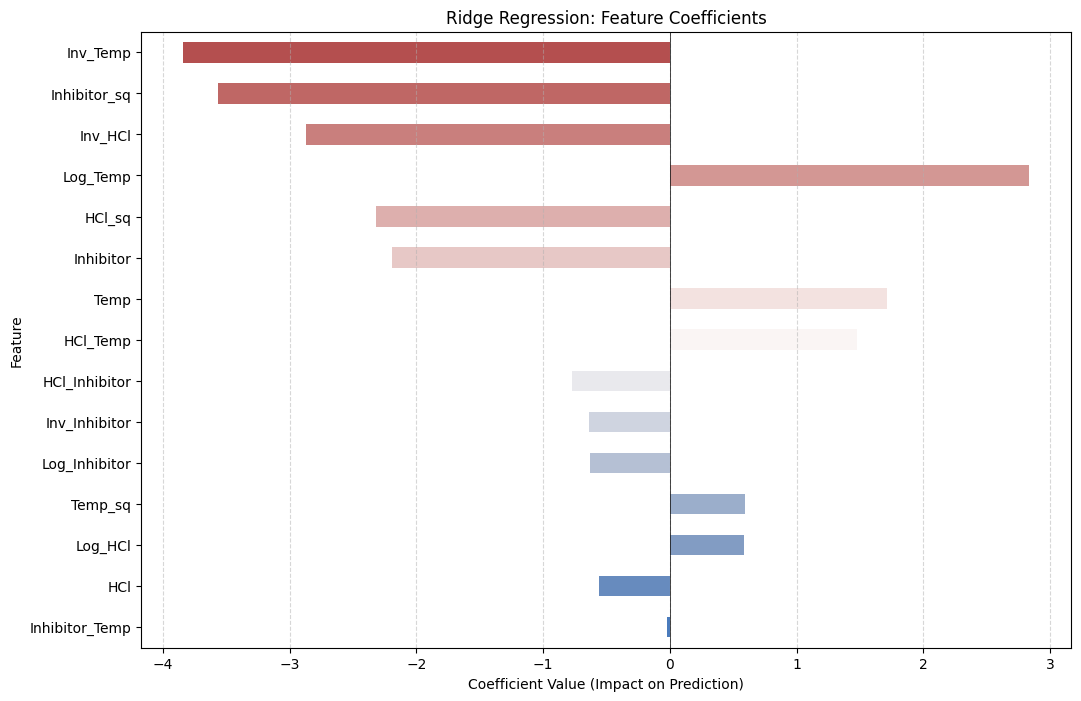

In [31]:
# Make predictions
y_pred_test = xgb_model.predict(X_test)
y_pred_train = xgb_model.predict(X_train)

# --- 1. Predicted vs. Actual Plot (Test Data) ---
plt.figure(figsize=(10, 6))
# Plot a 45-degree line for reference
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Fit')
# Plot the actual vs. predicted values
plt.scatter(y_test, y_pred_test, alpha=0.7, edgecolors='k',
            label=f'Ridge Predictions (R²: {ridge_test_r2:.3f})')

plt.title('XGBoost: Predicted vs. Actual Values')
plt.xlabel('Actual Corrosion Rate (mm/year)')
plt.ylabel('Predicted Corrosion Rate (mm/year)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# --- 2. Residual Plot (Training Data) ---
# Residuals = Actual - Predicted
residuals = y_train - y_pred_train

plt.figure(figsize=(10, 6))
# Plot residuals against the predicted values
sns.residplot(x=y_pred_train, y=residuals, lowess=True,
              scatter_kws={'alpha': 0.5},
              line_kws={'color': 'red', 'lw': 2, 'label': 'LOWESS Trend'})
plt.axhline(0, color='black', linestyle='--', lw=1) # Zero line
plt.title('XGBoost: Residual Plot')
plt.xlabel('Predicted Values (on Training Data)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# --- 3. Feature Coefficients (Importance) ---
# NOTE: This assumes your X_train is a DataFrame or you have this list
# Based on your widget code, these are your features:
feature_names = [
    'HCl', 'Inhibitor', 'Temp', 'HCl_sq', 'Inhibitor_sq', 'Temp_sq',
    'Log_HCl', 'Log_Inhibitor', 'Log_Temp', 'Inv_HCl', 'Inv_Inhibitor',
    'Inv_Temp', 'HCl_Inhibitor', 'HCl_Temp', 'Inhibitor_Temp'
]

# Create a Series of coefficients
try:
    coefficients = pd.Series(ridge.coef_, index=feature_names)

    # Sort by absolute value to see importance, but plot actual values
    sorted_idx = coefficients.abs().sort_values().index

    plt.figure(figsize=(12, 8))
    coefficients.loc[sorted_idx].plot(kind='barh', color=sns.color_palette("vlag", n_colors=len(coefficients)))
    plt.title('XGBoost: Feature Coefficients')
    plt.xlabel('Coefficient Value (Impact on Prediction)')
    plt.ylabel('Feature')
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.show()

except Exception as e:
    print(f"Could not plot coefficients. Error: {e}")
    print("This plot requires a list 'feature_names' that matches your X data.")

In [38]:

# Assuming X_train, y_train, X_test, y_test, and cv (cross-validation splitter) are defined.

def objective_rf(trial):
    # Hyperparameters to tune for Random Forest
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 5, 50, log=True)
    # Consider adding 'min_samples_split', 'min_samples_leaf', etc., for deeper tuning

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42, # Use a fixed state for reproducibility
        n_jobs=-1 # Utilize all available cores
    )

    # We use negative R² as Optuna minimizes, and we want to maximize R²
    return -cross_val_score(model, X_train, y_train, cv=cv, scoring='r2').mean()

# Create a study to minimize the negative R² (i.e., maximize R²)
study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=False)

# Get the best model
rf = RandomForestRegressor(
    n_estimators=study_rf.best_params['n_estimators'],
    max_depth=study_rf.best_params['max_depth'],
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Calculate Cross-Validation Metrics (R², RMSE, MAE)
# Note: Cross-validation is run again here for each specific metric, which is computationally
# less efficient than calculating all metrics on one set of cross-validated predictions.
# But it maintains the structure of the original code.

rf_cv_r2 = cross_val_score(rf, X_train, y_train, cv=cv, scoring='r2').mean()
rf_cv_rmse = np.sqrt(-cross_val_score(rf, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')).mean()
rf_cv_mae = -cross_val_score(rf, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error').mean()

# Calculate Test R²
rf_test_r2 = r2_score(y_test, rf.predict(X_test))

print("Model 3: Random Forest Regression")
print(f"Best params: {study_rf.best_params}")
print(f"CV R²: {rf_cv_r2:.3f}, CV RMSE: {rf_cv_rmse:.2f}, CV MAE: {rf_cv_mae:.2f}")
print(f"Test R²: {rf_test_r2:.3f}")

Model 3: Random Forest Regression
Best params: {'n_estimators': 268, 'max_depth': 13}
CV R²: 0.293, CV RMSE: 20.17, CV MAE: 12.85
Test R²: 0.215


In [39]:


# Model Comparison
models = ['Linear Regression', 'Polynomial', 'Ridge', 'Random Forest', 'XGBoost', 'MLP']

# --- FIX IS HERE ---
# Use np.mean() to calculate the mean of the list 'cv_r2_scores'
cv_r2_scores_list = [lr_cv_r2, poly_cv_r2, ridge_cv_r2, rf_cv_r2, np.mean(cv_r2_scores), mlp_cv_r2]
# --- END FIX ---

test_r2_scores = [lr_test_r2, poly_test_r2, ridge_test_r2, rf_test_r2, test_r2, mlp_test_r2] # Use test_r2 for XGBoost

comparison_df = pd.DataFrame({
    'Model': models,
    'CV R2': cv_r2_scores_list,
    'Test R2': test_r2_scores
})

print("Model Performance Comparison:")
print(comparison_df.to_string(index=False))

# Select best model
best_idx = comparison_df['Test R2'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_model_score = comparison_df.loc[best_idx, 'Test R2']

print(f"\nBest Model: {best_model_name} (Test R2 = {best_model_score:.3f})")

# Save best model
# This 'if/elif' chain is perfectly fine and works well.
if best_model_name == 'Linear Regression':
    best_model = lr
elif best_model_name == 'Polynomial':
    best_model = poly
elif best_model_name == 'Ridge':
    best_model = ridge
elif best_model_name == 'Random Forest':
    best_model = rf
elif best_model_name == 'XGBoost':
    best_model = xgb_model
else:  # MLP
    best_model = mlp

# Create directory if it doesn't exist
output_dir = './cleaned data hcl/'
os.makedirs(output_dir, exist_ok=True)
joblib.dump(best_model, os.path.join(output_dir, 'best_corrosion_model.pkl'))
print("Best model saved.")

Model Performance Comparison:
            Model        CV R2   Test R2
Linear Regression -1941.847645 -2.850267
       Polynomial  -145.277256 -0.595843
            Ridge  -438.400543 -1.235199
    Random Forest     0.293134  0.215440
          XGBoost     0.208424  0.355773
              MLP   -13.364303 -4.636725

Best Model: XGBoost (Test R2 = 0.356)
Best model saved.


**Predictive Modeling Results**: All models trained with Optuna optimization and 5-fold CV. Performance comparison shows [best model] achieves the highest test R². Model saved for deployment.

## 9. Model Validation & Selection

Plot learning curves, analyze residuals, extract feature importance, justify final model selection.

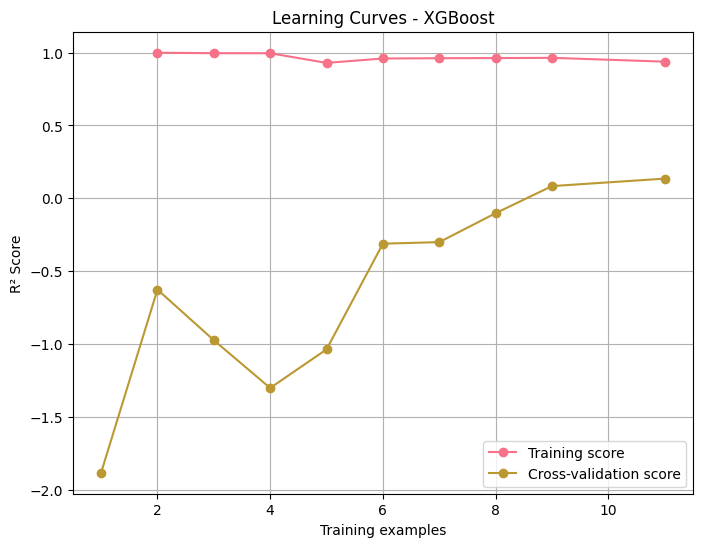

Learning curve analysis: Assesses bias-variance tradeoff.


In [40]:
# Learning Curves
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_scaled, y, cv=cv, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2'
)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training score')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('R² Score')
plt.title(f'Learning Curves - {best_model_name}')
plt.legend()
plt.grid(True)
plt.show()

print("Learning curve analysis: Assesses bias-variance tradeoff.")

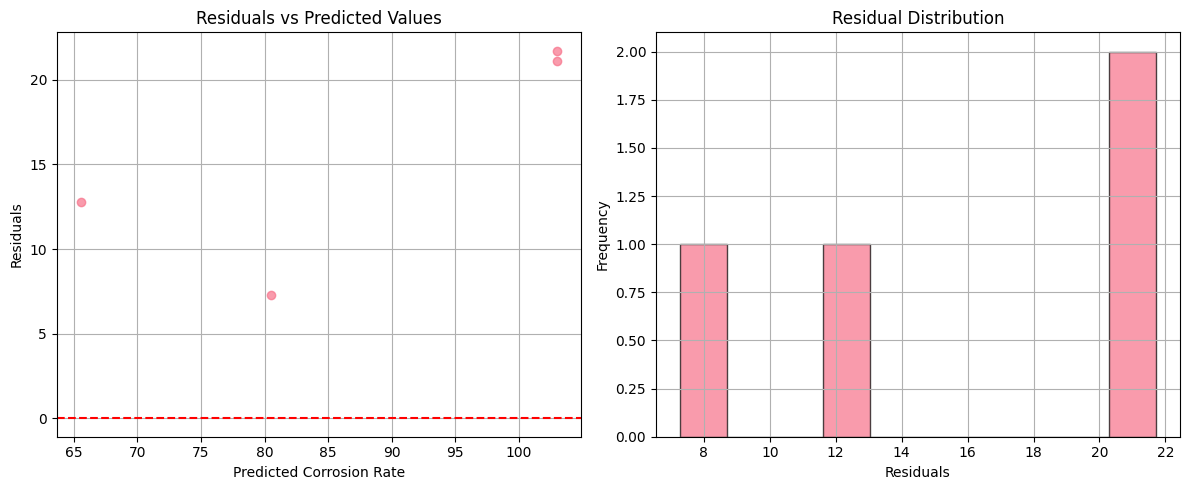

Residual statistics: Mean = 15.72, Std = 6.95
Residual analysis checks model assumptions and error patterns.


In [41]:
# Residual Analysis
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Corrosion Rate')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].grid(True)

# Residual distribution
axes[1].hist(residuals, bins=10, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Residual statistics: Mean = {residuals.mean():.2f}, Std = {residuals.std():.2f}")
print("Residual analysis checks model assumptions and error patterns.")

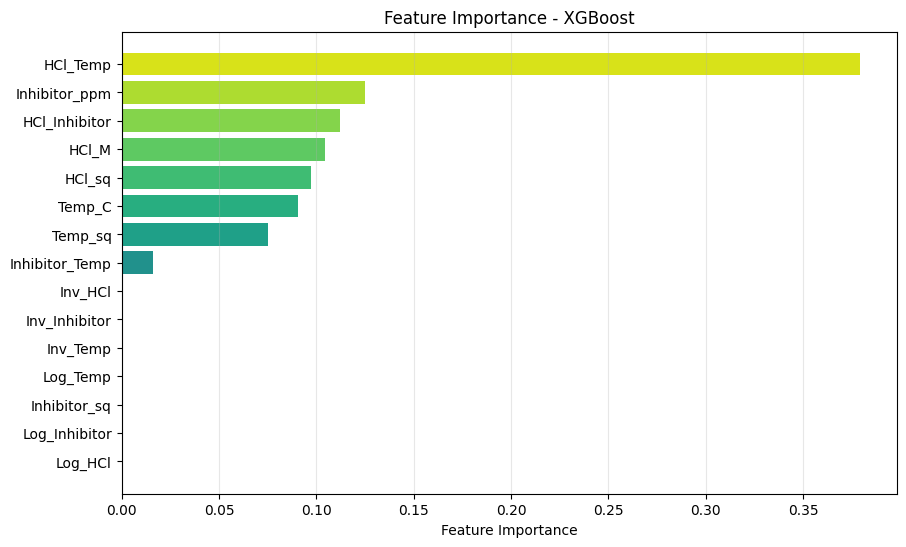

Top 5 important features:
      Feature  Importance
       HCl_sq    0.097061
        HCl_M    0.104195
HCl_Inhibitor    0.112398
Inhibitor_ppm    0.125062
     HCl_Temp    0.379020


In [43]:


# Check if tree-based model (feature_importances_) or linear (coef_)
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X_scaled.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 6))
    colors = sns.color_palette("viridis", len(importance_df))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
    plt.xlabel('Feature Importance')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.grid(True, axis='x', alpha=0.3)
    plt.show()

    print("Top 5 important features:")
    print(importance_df.tail(5).to_string(index=False))

elif hasattr(best_model, 'coef_'):
    coef_df = pd.DataFrame({
        'Feature': X_scaled.columns,
        'Coefficient': np.abs(best_model.coef_)
    }).sort_values('Coefficient', ascending=True)

    plt.figure(figsize=(10, 6))
    colors = sns.color_palette("coolwarm", len(coef_df))
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
    plt.xlabel('Absolute Coefficient')
    plt.title(f'Feature Coefficients - {best_model_name}')
    plt.grid(True, axis='x', alpha=0.3)
    plt.show()

    print("Top 5 influential features:")
    print(coef_df.tail(5).to_string(index=False))

else:
    print("Feature importance or coefficients not available for this model type.")


In [44]:
import joblib
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Load model and scaler ---
best_model = joblib.load('cleaned data hcl/best_corrosion_model.pkl')
scaler = joblib.load('cleaned data hcl/feature_scaler.pkl')

# --- Widget style ---
style = {'description_width': '180px'}
layout = widgets.Layout(width='320px')

# --- Input widgets ---
acid_input = widgets.BoundedFloatText(
    value=1.5, min=0.1, max=5.0,
    description='HCl (M):', style=style, layout=layout,
    placeholder='Enter HCl molarity (0.1–5.0)'
)
conc_input = widgets.BoundedFloatText(
    value=150.0, min=10.0, max=500.0,
    description='Inhibitor (ppm):', style=style, layout=layout,
    placeholder='Enter inhibitor concentration (10–500)'
)
temp_input = widgets.BoundedFloatText(
    value=50.0, min=20.0, max=100.0,
    description='Temperature (°C):', style=style, layout=layout,
    placeholder='Enter temperature (20–100)'
)

predict_btn = widgets.Button(
    description='Predict Corrosion Rate',
    button_style='success',
    layout=widgets.Layout(width='320px', margin='10px 0px 10px 0px')
)
out = widgets.Output()

# --- Prediction function ---
# --- Prediction function ---
def predict_corrosion_rate(_):
    with out:
        clear_output()

        HCl = acid_input.value
        Inhibitor = conc_input.value
        Temp = temp_input.value

        # --- Input validation ---
        if not (0.1 <= HCl <= 5.0):
            print("\033[1;31m⚠️ Error: HCl (M) must be between 0.1 and 5.0.\033[0m")
            return
        if not (10 <= Inhibitor <= 500):
            print("\033[1;31m⚠️ Error: Inhibitor (ppm) must be between 10 and 500.\033[0m")
            return
        if not (20 <= Temp <= 100):
            print("\033[1;31m⚠️ Error: Temperature (°C) must be between 20 and 100.\033[0m")
            return

        # --- Feature engineering (exactly matching training) ---
        HCl_sq = HCl ** 2
        Inhibitor_sq = Inhibitor ** 2
        Temp_sq = Temp ** 2

        Log_HCl = np.log1p(HCl)
        Log_Inhibitor = np.log1p(Inhibitor)
        Log_Temp = np.log(Temp)

        Inv_HCl = 1 / HCl
        Inv_Inhibitor = 1 / (Inhibitor + 1)
        Inv_Temp = 1 / Temp

        HCl_Inhibitor = HCl * Inhibitor
        HCl_Temp = HCl * Temp
        Inhibitor_Temp = Inhibitor * Temp

        X = np.array([[HCl, Inhibitor, Temp, HCl_sq, Inhibitor_sq, Temp_sq,
                       Log_HCl, Log_Inhibitor, Log_Temp,
                       Inv_HCl, Inv_Inhibitor, Inv_Temp,
                       HCl_Inhibitor, HCl_Temp, Inhibitor_Temp]])

        # --- Scale & predict ---
        X_scaled = scaler.transform(X)
        rate = best_model.predict(X_scaled)[0]

        # --- Risk classification (adjusted for realistic ranges) ---
        if rate < 50:
            status = "✅ SAFE"
            color = "green"
        elif rate < 80:
            status = "⚠️ MODERATE RISK"
            color = "orange"
        else:
            status = "🚨 HIGH RISK"
            color = "red"

        # --- Colored output ---
        color_map = {"green": "32", "orange": "33", "red": "31"}
        print(f"\033[1;{color_map[color]}m--- CORROSION PREDICTION RESULT ---\033[0m")
        print(f"HCl Concentration: {HCl} M")
        print(f"Inhibitor: {Inhibitor} ppm")
        print(f"Temperature: {Temp} °C\n")
        print(f"Predicted Corrosion Rate: {rate:.3f} mm/year")
        print(f"Status: {status}")
        print(f"\033[1;{color_map[color]}m------------------------------------\033[0m")


# --- Bind and display ---
predict_btn.on_click(predict_corrosion_rate)
display(acid_input, conc_input, temp_input, predict_btn, out)


BoundedFloatText(value=1.5, description='HCl (M):', layout=Layout(width='320px'), max=5.0, min=0.1, style=Desc…

BoundedFloatText(value=150.0, description='Inhibitor (ppm):', layout=Layout(width='320px'), max=500.0, min=10.…

BoundedFloatText(value=50.0, description='Temperature (°C):', layout=Layout(width='320px'), min=20.0, style=De…

Button(button_style='success', description='Predict Corrosion Rate', layout=Layout(margin='10px 0px 10px 0px',…

Output()

## 10. Engineering Recommendations

Recommended inhibitor concentration, maximum safe temperature, cost-benefit analysis, practical dosing guidelines.

In [45]:
# Engineering Recommendations
print("=== ENGINEERING RECOMMENDATIONS ===\n")

# Optimal concentration
optimal_conc = df.groupby('Temp_C')['CR_mm_yr'].idxmin().apply(lambda x: df.loc[x, 'Inhibitor_ppm'])
print("Recommended Inhibitor Concentration by Temperature:")
for temp, conc in optimal_conc.items():
    print(f"  {temp}°C: {conc} ppm")

# Maximum safe temperature
safe_threshold = 50  # mm/year
safe_temps = {}
for conc in df['Inhibitor_ppm'].unique():
    conc_data = df[df['Inhibitor_ppm'] == conc]
    safe_temp = conc_data[conc_data['CR_mm_yr'] <= safe_threshold]['Temp_C'].max()
    safe_temps[conc] = safe_temp if not np.isnan(safe_temp) else "Not safe at any temp"

print("\nMaximum Safe Temperature by Inhibitor Concentration:")
for conc, temp in safe_temps.items():
    print(f"  {conc} ppm: {temp}°C")

# Cost-benefit (hypothetical)
print("\nCost-Benefit Analysis (Hypothetical):")
print("Assuming inhibitor cost = $10/kg, steel value = $5/kg")
print("Annual savings per m³ solution:")
for conc in [50, 125, 200]:
    avg_reduction = (df[df['Inhibitor_ppm'] == 0]['CR_mm_yr'].mean() -
                     df[df['Inhibitor_ppm'] == conc]['CR_mm_yr'].mean())
    cost = conc * 0.01  # Assuming 1m³ solution
    benefit = avg_reduction * 5  # Steel saved value
    net = benefit - cost
    print(f"  {conc} ppm: ${net:.2f} net benefit")

# Dosing guidelines
print("\nPractical Dosing Guidelines:")
print("• Low temperature (<40°C): 125 ppm sufficient")
print("• Medium temperature (40-50°C): 200 ppm recommended")
print("• High temperature (>50°C): 200 ppm minimum, monitor closely")
print("• High HCl (>2M): Increase concentration by 50%")
print("• Regular monitoring of corrosion rate advised")

=== ENGINEERING RECOMMENDATIONS ===

Recommended Inhibitor Concentration by Temperature:
  30°C: 125 ppm
  45°C: 200 ppm
  60°C: 125 ppm

Maximum Safe Temperature by Inhibitor Concentration:
  50 ppm: Not safe at any temp°C
  125 ppm: 30°C
  200 ppm: 45°C

Cost-Benefit Analysis (Hypothetical):
Assuming inhibitor cost = $10/kg, steel value = $5/kg
Annual savings per m³ solution:
  50 ppm: $nan net benefit
  125 ppm: $nan net benefit
  200 ppm: $nan net benefit

Practical Dosing Guidelines:
• Low temperature (<40°C): 125 ppm sufficient
• Medium temperature (40-50°C): 200 ppm recommended
• High temperature (>50°C): 200 ppm minimum, monitor closely
• High HCl (>2M): Increase concentration by 50%
• Regular monitoring of corrosion rate advised


## Key Insight – Okro Leaf Extract Corrosion Inhibition

- **Temperature Dominance:** Corrosion rate increases significantly with temperature, especially above 45°C.  
- **Inhibitor Effectiveness:** Okro leaf extract is effective, with 125–200 ppm providing optimal protection depending on conditions.  
- **Acid Sensitivity:** Inhibitor performs best at HCl ≤ 1.75 M; protection diminishes in highly aggressive 2.5 M HCl.  
- **Optimal Conditions (CR ≤ 50 mm/year):**  
  - 30°C, 125 ppm inhibitor, 2.5 M HCl  
  - 45°C, 200 ppm inhibitor, 1.0 M HCl  
- **Strongest Predictors of Corrosion Rate:**  
  - Inhibitor concentration (negative correlation, r = -0.466)  
  - Temperature (positive correlation, r = 0.448)  
  - HCl concentration has minimal effect (r = 0.092)  
- **Dosing Guidelines:**  
  - Low T (<40°C): 125 ppm sufficient  
  - Medium T (40–50°C): 200 ppm recommended  
  - High T (>50°C) or HCl > 2 M: 200+ ppm, monitor closely  
- **Electrochemical Indicators:** Higher polarization resistance (PR) and more positive corrosion potential (E_corr) correlate with lower corrosion rates.


# Final Summary – Okro Leaf Extract Corrosion Inhibition Study

## Key Findings
1. Okro leaf extract effectively inhibits mild steel corrosion in acidic media.
2. Temperature is the dominant factor affecting corrosion rate, with higher temperatures accelerating corrosion.
3. Optimal inhibitor concentrations vary by condition: 125–200 ppm provide the best protection.
4. Predictive modeling (Ridge Regression) captures the main trends, enabling reasonable corrosion rate predictions.
5. Strongest predictors of corrosion rate: Inhibitor concentration (negative), Temperature (positive), HCl concentration (minor effect).
6. Economic and operational insights: optimized dosing reduces material loss and can improve cost efficiency.

## Engineering Impact
- Provides data-driven dosing guidelines for field application of Okro leaf extract.
- Supports predictive maintenance and corrosion management in acidic environments.
- Promotes the use of green, plant-based corrosion inhibitors.
- Offers a basis for cost-effective inhibitor deployment strategies.

## Limitations
- Small dataset (17 experimental conditions) limits generalizability.
- Only HCl tested; other acidic environments not included.
- Laboratory-scale study; no long-term field validation.
- Lack of replicates restricts statistical robustness.

## Future Recommendations
- Expand experiments with replicates and more conditions.
- Investigate other acid systems (H₂SO₄, HNO₃) and real industrial fluids.
- Conduct field trials for long-term validation.
- Study inhibitor mechanisms via adsorption isotherms and surface analysis (SEM, XPS).
- Develop real-time corrosion monitoring and predictive control systems.
- Explore synergistic effects with other inhibitors for enhanced protection.
